In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fraud-dataset-finalyrproject/fraud_dataset1.0.csv



This project will have a machine learning model which can predict whether a transaction is fraudulent or not.

1.  Data Description
2.  Feature Engineering
3.  Data Filtering
4.  Exploratory Data Analysis
5.  Data Preparation
6.  Feature Selection
7.  Machine Learning Modeling
8.  Hyperparameter Fine Tuning
9.  Conclusions

# Key notes

Okay, let's take a small, simplified sample dataset for fraud detection and explain each of those metrics.

**Sample Scenario:**

Imagine we have a model that has predicted fraud for 10 transactions. We then compare these predictions to the actual outcomes.

*   **TP (True Positive):** Model correctly predicts fraud.
*   **FP (False Positive):** Model incorrectly predicts fraud (it was actually legitimate). (Type I error)
*   **FN (False Negative):** Model incorrectly predicts legitimate (it was actually fraud). (Type II error)
*   **TN (True Negative):** Model correctly predicts legitimate.

**Let's say our model's performance on these 10 transactions resulted in:**

*   **Actual Fraud Cases:** 3
*   **Actual Legitimate Cases:** 7

**Model Predictions & Outcomes:**

| Transaction | Actual        | Predicted     | Outcome          |
| :---------- | :------------ | :------------ | :--------------- |
| 1           | Fraud         | Fraud         | **TP (True Positive)** |
| 2           | Fraud         | Fraud         | **TP (True Positive)** |
| 3           | Fraud         | Legitimate    | **FN (False Negative)** |
| 4           | Legitimate    | Fraud         | **FP (False Positive)** |
| 5           | Legitimate    | Legitimate    | **TN (True Negative)** |
| 6           | Legitimate    | Legitimate    | **TN (True Negative)** |
| 7           | Legitimate    | Legitimate    | **TN (True Negative)** |
| 8           | Legitimate    | Legitimate    | **TN (True Negative)** |
| 9           | Legitimate    | Legitimate    | **TN (True Negative)** |
| 10          | Legitimate    | Legitimate    | **TN (True Negative)** |

**From this table, we have:**
*   **TP = 2** (Model said "Fraud", and it *was* Fraud)
*   **FP = 1** (Model said "Fraud", but it was Legitimate)
*   **FN = 1** (Model said "Legitimate", but it *was* Fraud)
*   **TN = 6** (Model said "Legitimate", and it *was* Legitimate)

Now let's calculate the metrics:

---

1.  **Precision**
    *   **Question it answers:** "Of all the transactions the model flagged as fraud, what proportion was *actually* fraudulent?"
    *   **Focus:** Minimizing false alarms (False Positives). High precision means when the model says it's fraud, it's usually right.
    *   **Formula:** `Precision = TP / (TP + FP)`
    *   **Calculation:** `2 / (2 + 1) = 2 / 3 = 0.667`
    *   **Interpretation:** 66.7% of the transactions our model predicted as fraud were actually fraudulent.

2.  **Recall (Sensitivity or True Positive Rate)**
    *   **Question it answers:** "Of all the *actual* fraudulent transactions, what proportion did the model correctly identify?"
    *   **Focus:** Minimizing missed frauds (False Negatives). High recall means the model is good at finding most of the actual frauds.
    *   **Formula:** `Recall = TP / (TP + FN)`
    *   **Calculation:** `2 / (2 + 1) = 2 / 3 = 0.667`
    *   **Interpretation:** Our model successfully detected 66.7% of all the actual fraudulent transactions that occurred.

3.  **F1-Score**
    *   **Question it answers:** "What is the balanced measure of Precision and Recall?"
    *   **Focus:** Provides a single score that balances the trade-off between precision and recall. It's useful when you care about both minimizing false alarms and minimizing missed frauds, especially in imbalanced datasets.
    *   **Formula:** `F1-Score = 2 * (Precision * Recall) / (Precision + Recall)`
    *   **Calculation:** `2 * (0.667 * 0.667) / (0.667 + 0.667) = 2 * 0.444889 / 1.334 = 0.889778 / 1.334 = 0.667`
    *   **Interpretation:** The F1-score is 0.667. A score closer to 1 is better. In this case, since precision and recall are equal, the F1-score is also the same.

4.  **Balanced Accuracy**
    *   **Question it answers:** "What is the average of the recall for each class?" (Or, how well does the model perform on both the positive and negative classes, considering potential imbalance?)
    *   **Focus:** Gives a better idea of overall accuracy when classes are imbalanced. Simple accuracy (`(TP+TN)/Total`) can be misleading if one class is very rare.
    *   **Formula:** `Balanced Accuracy = (Sensitivity + Specificity) / 2`
        *   Sensitivity (Recall for fraud class) = `TP / (TP + FN) = 2 / (2 + 1) = 2/3 = 0.667`
        *   Specificity (Recall for legitimate class) = `TN / (TN + FP) = 6 / (6 + 1) = 6/7 = 0.857`
    *   **Calculation:** `(0.667 + 0.857) / 2 = 1.524 / 2 = 0.762`
    *   **Interpretation:** The model's balanced accuracy is 76.2%. This gives a more nuanced view than simple accuracy, especially since our fraud class is smaller.
        *   *Simple Accuracy for comparison*: `(TP + TN) / (TP+FP+FN+TN) = (2+6) / 10 = 8/10 = 0.80` or 80%. Notice how balanced accuracy is lower here because it penalizes the poor recall on the smaller fraud class more.

5.  **Kappa (Cohen's Kappa Coefficient)**
    *   **Question it answers:** "How much better is the model's performance compared to a random chance agreement?"
    *   **Focus:** Measures the agreement between the predicted and actual classifications, while correcting for the agreement that might occur by chance.
    *   **Formula:** `Kappa = (Po - Pe) / (1 - Pe)`
        *   `Po` = Observed agreement = (TP + TN) / Total = (2 + 6) / 10 = 0.8
        *   `Pe` = Expected agreement by chance. This is a bit more complex:
            *   `Pe_fraud = ((TP+FN)/Total) * ((TP+FP)/Total) = (3/10) * (3/10) = 0.09`
            *   `Pe_legitimate = ((FP+TN)/Total) * ((FN+TN)/Total) = (7/10) * (7/10) = 0.49`
            *   `Pe = Pe_fraud + Pe_legitimate = 0.09 + 0.49 = 0.58`
    *   **Calculation:** `(0.8 - 0.58) / (1 - 0.58) = 0.22 / 0.42 = 0.524`
    *   **Interpretation:**
        *   Kappa values range from -1 to 1.
        *   1 indicates perfect agreement.
        *   0 indicates agreement equivalent to chance.
        *   Negative values indicate agreement worse than chance.
        *   A Kappa of 0.524 suggests a moderate level of agreement between the model's predictions and the actual outcomes, better than what would be expected by random guessing.

**Summary for the Example:**

*   **Precision (0.667):** When it says fraud, it's right 2/3 of the time.
*   **Recall (0.667):** It catches 2/3 of the actual frauds.
*   **F1-Score (0.667):** A balanced measure of precision and recall.
*   **Balanced Accuracy (0.762):** A good overall accuracy considering class imbalance.
*   **Kappa (0.524):** The model shows moderate agreement, performing better than random chance.

These metrics together give a comprehensive picture of the model's performance, highlighting its strengths and weaknesses in identifying fraud. For instance, while the precision and recall are decent, there's still room for improvement in catching all frauds (increasing recall) without wrongly flagging too many legitimate ones (maintaining or increasing precision).

In [2]:
!pip install inflection


# 0.0 Project Setup and Initialization
## 0.1 Importing Necessary Libraries

In [3]:
import joblib
import warnings
import inflection

import numpy             as np
import pandas            as pd
import seaborn           as sns

import matplotlib.pyplot as plt

from scipy   import stats
from boruta  import BorutaPy
from category_encoders import OneHotEncoder

from IPython.display      import Image
from IPython.core.display import HTML 

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.svm          import SVC
from sklearn.dummy        import DummyClassifier
from sklearn.ensemble     import RandomForestClassifier
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics         import balanced_accuracy_score, precision_score, classification_report
from sklearn.metrics         import recall_score, f1_score, make_scorer, cohen_kappa_score
from sklearn.preprocessing   import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold

Okay, here's a short and precise explanation of each import's use with an example:

*   **`import joblib`**: Saves/loads Python objects (e.g., trained models).
    *   Ex: `joblib.dump(model, 'model.pkl')`
*   **`import warnings`**: Manages warning messages.
    *   Ex: `warnings.filterwarnings('ignore')` (to hide warnings).
*   **`import inflection`**: Converts string cases (e.g., CamelCase to snake\_case).
    *   Ex: `inflection.underscore("MyColumn")` -> `my_column`.
*   **`import numpy as np`**: For numerical operations, especially arrays.
    *   Ex: `np.mean(my_array)`
*   **`import pandas as pd`**: For data manipulation with DataFrames (like spreadsheets).
    *   Ex: `df = pd.read_csv('data.csv')`
*   **`import seaborn as sns`**: For statistical data visualization.
    *   Ex: `sns.histplot(df['age'])`
*   **`import matplotlib.pyplot as plt`**: For basic plotting.
    *   Ex: `plt.plot(x, y)`
*   **`from scipy import stats`**: For statistical functions.
    *   Ex: `stats.ttest_ind(group1, group2)`
*   **`from boruta import BorutaPy`**: Feature selection algorithm.
    *   Ex: `boruta_selector = BorutaPy(RandomForestClassifier()); boruta_selector.fit(X, y)`
*   **`from category_encoders import OneHotEncoder`**: For converting categorical data to numbers.
    *   Ex: `encoder = OneHotEncoder(cols=['color']); df_encoded = encoder.fit_transform(df)`
*   **`from IPython.display import Image`**: Displays images in notebooks.
    *   Ex: `Image('my_image.png')`
*   **`from IPython.core.display import HTML`**: Renders HTML in notebooks.
    *   Ex: `HTML('<h1>Title</h1>')`
*   **`from xgboost import XGBClassifier`**: XGBoost classification model.
    *   Ex: `model = XGBClassifier(); model.fit(X_train, y_train)`
*   **`from lightgbm import LGBMClassifier`**: LightGBM classification model.
    *   Ex: `model = LGBMClassifier(); model.fit(X_train, y_train)`
*   **`from sklearn.svm import SVC`**: Support Vector Machine classifier.
    *   Ex: `model = SVC(); model.fit(X_train, y_train)`
*   **`from sklearn.dummy import DummyClassifier`**: Basic baseline classifier.
    *   Ex: `dummy = DummyClassifier(strategy='most_frequent'); dummy.fit(X_train, y_train)`
*   **`from sklearn.ensemble import RandomForestClassifier`**: Random Forest classification model.
    *   Ex: `model = RandomForestClassifier(); model.fit(X_train, y_train)`
*   **`from sklearn.neighbors import KNeighborsClassifier`**: K-Nearest Neighbors classifier.
    *   Ex: `model = KNeighborsClassifier(); model.fit(X_train, y_train)`
*   **`from sklearn.linear_model import LogisticRegression`**: Logistic Regression model.
    *   Ex: `model = LogisticRegression(); model.fit(X_train, y_train)`
*   **`from sklearn.metrics import ...` (various)**: For evaluating model performance.
    *   Ex: `f1 = f1_score(y_true, y_pred)`
    *   Ex: `print(classification_report(y_true, y_pred))`
*   **`from sklearn.preprocessing import MinMaxScaler`**: Scales numerical features to a 0-1 range.
    *   Ex: `scaler = MinMaxScaler(); X_scaled = scaler.fit_transform(X)`
*   **`from sklearn.model_selection import ...` (various)**: For splitting data and tuning models.
    *   Ex: `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)`
    *   Ex: `gs = GridSearchCV(model, params); gs.fit(X_train, y_train)`

# 0.2 Custom Utility Functions

In [4]:
warnings.filterwarnings('ignore')

seed = 42
np.random.seed(seed)

Okay, here's a short and precise explanation:

*   **`warnings.filterwarnings('ignore')`**
    *   **Use:** Hides warning messages generated by Python or libraries.
    *   **Ex:** Prevents your notebook output from being cluttered with non-critical alerts (e.g., about a feature that will be changed in a future library version).

*   **`seed = 42`**
    *   **Use:** Assigns the number `42` to a variable named `seed`. This number will be used to initialize random processes.
    *   **Ex:** `seed` is just a placeholder for the value 42 here.

*   **`np.random.seed(seed)`**
    *   **Use:** Initializes NumPy's random number generator with a specific starting point (`seed`, which is 42).
    *   **Ex:** Ensures that any operation using NumPy's random functions (like `np.random.shuffle()` for splitting data) will produce the exact same "random" results every time you run the code, making your experiments reproducible.

No, there's **no special mathematical or statistical reason** to choose 42 over any other integer for `seed = 42`.

*   **Purpose:** The number itself is arbitrary. Its only job is to provide a fixed starting point for the random number generator.
*   **Why 42?** It's a popular, conventional choice in programming and data science, largely as an anecdotical reference to "The Hitchhiker's Guide to the Galaxy" by Douglas Adams, where 42 is "the Answer to the Ultimate Question of Life, the Universe, and Everything."
*   **Could it be another number?** Absolutely. `seed = 0`, `seed = 123`, or `seed = 1000` would all work just as well to ensure reproducibility. The key is consistency: using the *same* seed will produce the *same* sequence of "random" numbers.

**In short: 42 is just a common, arbitrary convention for a random seed, chosen for its cultural reference. Any other integer would serve the same purpose of ensuring reproducibility.**

In [5]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline
    
    sns.set(font_scale=1.6)
    
    plt.style.use('seaborn-darkgrid')
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 16
    
    display( HTML('<style>.container { width:100% !important; }</style>'))
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
jupyter_settings()

Populating the interactive namespace from numpy and matplotlib


Here's a short and precise explanation:

**`def jupyter_settings(): ...`**
*   **Use:** Defines a function to customize the Jupyter Notebook environment for better display of plots and pandas DataFrames.
*   **`jupyter_settings()`**: Calls the function to apply these settings.

**Inside the function:**

*   **`%matplotlib inline` & `%pylab inline`**:
    *   **Use:** Magic commands to make plots appear directly in the notebook output cells. `%pylab` also imports common NumPy/Matplotlib functions.
    *   **Ex:** `plt.plot(x,y)` will show the graph below the code.
*   **`sns.set(font_scale=1.6)`**:
    *   **Use:** Increases default font size in Seaborn plots for readability.
    *   **Ex:** Titles and labels on Seaborn charts will be 1.6 times larger.
*   **`plt.style.use('seaborn-darkgrid')`**:
    *   **Use:** Applies a visually appealing style (dark grid) to Matplotlib plots.
    *   **Ex:** Matplotlib plots will have a consistent, modern look.
*   **`plt.rcParams['figure.figsize'] = [25, 12]` & `plt.rcParams['font.size'] = 16`**:
    *   **Use:** Sets default large figure size (25x12 inches) and font size (16pt) for Matplotlib plots.
    *   **Ex:** New plots will automatically be larger and have bigger text.
*   **`display(HTML('<style>... width:100% ...</style>'))`**:
    *   **Use:** Makes the notebook content area use the full browser width.
    *   **Ex:** Useful for displaying wide tables or plots without horizontal scrolling.
*   **`pd.options.display.max_columns = None` & `pd.options.display.max_rows = None`**:
    *   **Use:** Tells pandas to show all columns and all rows when displaying a DataFrame, instead of truncating.
    *   **Ex:** `print(my_large_df)` will show everything.
*   **`pd.set_option('display.expand_frame_repr', False)`**:
    *   **Use:** Prevents pandas from wrapping wide DataFrames onto multiple lines when printing.
    *   **Ex:** Wide DataFrames will display as one wide block.

In [6]:
def ml_scores(model_name, y_true, y_pred):
    
    accuracy = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    
    return pd.DataFrame({'Balanced Accuracy': np.round(accuracy, 3), 
                         'Precision': np.round(precision, 3), 
                         'Recall': np.round(recall, 3),
                         'F1': np.round(f1, 3),
                         'Kappa': np.round(kappa, 3)}, 
                        index=[model_name])

In [7]:
def calcCramerV(x, y):
    cm = pd.crosstab(x, y).values
    n = cm.sum()
    r, k = cm.shape
    
    chi2 = stats.chi2_contingency(cm)[0]
    chi2corr = max(0, chi2 - (k-1)*(r-1)/(n-1))
    
    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (r-1)**2/(n-1)
    
    return np.sqrt((chi2corr/n) / (min(kcorr-1, rcorr-1)))

Okay, here's a short and precise explanation of these two helper functions:

---

1.  **`def ml_scores(model_name, y_true, y_pred):`**
    *   **Purpose:** Calculates and returns common classification metrics for a model's predictions.
    *   **Inputs:**
        *   `model_name` (str): The name of the model (e.g., "Logistic Regression").
        *   `y_true` (array-like): The true actual labels.
        *   `y_pred` (array-like): The labels predicted by the model.
    *   **Calculates:** Balanced Accuracy, Precision, Recall, F1-score, and Cohen's Kappa.
    *   **Output:** A pandas DataFrame with these scores (rounded to 3 decimal places), indexed by `model_name`.
    *   **Example Use:** `results_df = ml_scores("MyModel", actual_labels, predicted_labels)`
    *   **Relevance:** Simplifies the process of evaluating and comparing different classification models by consolidating key metrics into a neat table.

---

2.  **`def calcCramerV(x, y):`**
    *   **Purpose:** Calculates Cramér's V, a measure of association between two categorical variables.
    *   **Inputs:**
        *   `x` (pandas Series or array-like): The first categorical variable.
        *   `y` (pandas Series or array-like): The second categorical variable.
    *   **Process:**
        1.  Creates a contingency table (cross-tabulation) of `x` and `y`.
        2.  Calculates the Chi-squared statistic from this table.
        3.  Applies a bias correction to Chi-squared.
        4.  Normalizes the corrected Chi-squared value to produce Cramér's V, which ranges from 0 (no association) to 1 (perfect association).
    *   **Output:** A float representing the Cramér's V value.
    *   **Example Use:** `association_strength = calcCramerV(df['transaction_type'], df['isFraud'])`
    *   **Relevance:** Used in Exploratory Data Analysis (EDA) to quantify the strength of relationship between categorical features, or between a categorical feature and the categorical target variable (`isFraud`).

---

In [8]:
def ml_cv_results(model_name, model, x, y, verbose=1):
    
    '''initial'''
    balanced_accuracies = []
    precisions = []
    recalls = []
    f1s = []
    kappas = []
    
    mm = MinMaxScaler()
    
    x_ = x.to_numpy()
    y_ = y.to_numpy()
    
    count = 0
    
    '''cross-validation'''
    skf = StratifiedKFold(n_splits=5, shuffle=True)
    
    for index_train, index_test in skf.split(x_, y_):
        ## Showing the Fold
        if verbose > 0:
            count += 1
            print('Fold K=%i' % (count))
    
        ## selecting train and test
        x_train, x_test = x.iloc[index_train], x.iloc[index_test]
        y_train, y_test = y.iloc[index_train], y.iloc[index_test]
        
        ## applying the scale
        x_train = mm.fit_transform(x_train)
        x_test = mm.transform(x_test)
    
        ## training the model
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        ## saving the metrics
        balanced_accuracies.append(balanced_accuracy_score(y_test, y_pred))
        precisions.append(precision_score(y_test, y_pred))
        recalls.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))
        kappas.append(cohen_kappa_score(y_test, y_pred))
        
        
    '''results'''    
    accuracy_mean, accuracy_std = np.round(np.mean(balanced_accuracies), 3), np.round(np.std(balanced_accuracies), 3)
    precision_mean, precision_std = np.round(np.mean(precisions), 3), np.round(np.std(precisions), 3)
    recall_mean, recall_std = np.round(np.mean(recalls), 3), np.round(np.std(recalls), 3)
    f1_mean, f1_std = np.round(np.mean(f1s), 3), np.round(np.std(f1s), 3)
    kappa_mean, kappa_std = np.round(np.mean(kappas), 3), np.round(np.std(kappas), 3)
    
    ## saving the results in a dataframe
    return pd.DataFrame({"Balanced Accuracy": "{} +/- {}".format(accuracy_mean, accuracy_std),
                        "Precision": "{} +/- {}".format(precision_mean, precision_std),
                        "Recall": "{} +/- {}".format(recall_mean, recall_std),
                        "F1": "{} +/- {}".format(f1_mean, f1_std),
                        "Kappa": "{} +/- {}".format(kappa_mean, kappa_std)},
                       index=[model_name])

Okay, here's a short and precise explanation of the `ml_cv_results` function:

**`def ml_cv_results(model_name, model, x, y, verbose=1):`**

*   **Purpose:** Performs 5-fold stratified cross-validation on a given machine learning `model` using features `x` and target `y` to provide a robust estimate of its performance.
*   **Inputs:**
    *   `model_name` (str): Name for identifying the model in results.
    *   `model`: The scikit-learn compatible model instance (e.g., `XGBClassifier()`).
    *   `x` (pd.DataFrame): Feature data.
    *   `y` (pd.Series): Target labels.
    *   `verbose` (int): Controls print statements for fold progress (default is 1 to show).
*   **Process:**
    1.  Initializes lists to store metrics for each fold.
    2.  Uses `StratifiedKFold` (5 splits, shuffled) to divide data, preserving class proportions in each fold.
    3.  **For each fold:**
        *   Splits data into a training and testing set for that fold.
        *   Applies `MinMaxScaler`: fits on the fold's training data and transforms both the fold's training and testing data (prevents data leakage).
        *   Trains the `model` on the scaled training data of the fold.
        *   Makes predictions on the scaled testing data of the fold.
        *   Calculates Balanced Accuracy, Precision, Recall, F1-score, and Cohen's Kappa for the fold.
    4.  After all folds, calculates the mean and standard deviation for each metric.
*   **Output:** A pandas DataFrame, indexed by `model_name`, displaying each metric as "mean +/- std" (e.g., "0.850 +/- 0.023").
*   **Example Use:** `cv_scores = ml_cv_results("XGBoost", xgb_model, X_features, y_target)`
*   **Relevance:** Provides a more reliable assessment of how the model is likely to perform on unseen data compared to a single train-test split. Crucial for understanding model stability and generalizability, especially with imbalanced data (thanks to `StratifiedKFold`).

Okay, let's explain the difference between the cross-validation approach used in `ml_cv_results` and a single train-test split, with an example.

**Single Train-Test Split**

*   **What it is:** You divide your dataset *once* into two parts: a training set and a testing set.
*   **Process:**
    1.  Split data (e.g., 70% for training, 30% for testing).
    2.  Train your model *only* on the training set.
    3.  Evaluate your model *only* on the testing set.
*   **Outcome:** You get one set of performance metrics (e.g., one recall score, one precision score).
*   **Problem:** The performance you observe can be highly dependent on *how* the data was split.
    *   If, by chance, your test set contains "easier" examples, your model might look better than it actually is.
    *   If your test set contains particularly "hard" or unrepresentative examples, your model might look worse.
    *   You don't get a sense of how stable your model's performance is.

**Cross-Validation (as in `ml_cv_results` using 5-Fold Stratified CV)**

*   **What it is:** You divide your dataset into multiple (e.g., 5) "folds" or sections. The model is trained and tested multiple times, using a different fold for testing each time and the remaining folds for training.
*   **Process (for 5-fold):**
    1.  Divide the dataset into 5 equal-sized folds (stratified means each fold tries to keep the same proportion of classes, e.g., fraud vs. non-fraud, as the original dataset).
    2.  **Iteration 1:** Train on Folds 1-4, Test on Fold 5. Calculate metrics.
    3.  **Iteration 2:** Train on Folds 1-3 & 5, Test on Fold 4. Calculate metrics.
    4.  **Iteration 3:** Train on Folds 1-2 & 4-5, Test on Fold 3. Calculate metrics.
    5.  **Iteration 4:** Train on Folds 1 & 3-5, Test on Fold 2. Calculate metrics.
    6.  **Iteration 5:** Train on Folds 2-5, Test on Fold 1. Calculate metrics.
*   **Outcome:** You get 5 sets of performance metrics. The `ml_cv_results` function then reports the **average** and **standard deviation** of these metrics.
*   **Advantage:**
    *   **More Robust Estimate:** The average performance across folds is a more reliable indicator of how your model will perform on unseen data because it has been tested on multiple, different subsets of your data.
    *   **Better Data Utilization:** Every data point gets to be in a test set exactly once and in a training set multiple times.
    *   **Performance Stability:** The standard deviation tells you how much the model's performance varied across different test folds. A low standard deviation means the model is consistently performing, while a high one suggests its performance is sensitive to the specific test data.

---

**Example: Fraud Detection**

Imagine you have 1000 transactions, with 100 (10%) being fraudulent.

*   **Single Train-Test Split (e.g., 70% train, 30% test):**
    *   **Train:** 700 transactions (maybe ~70 fraud).
    *   **Test:** 300 transactions (maybe ~30 fraud).
    *   You train your model on the 700, test on the 300, and get, say, a **Recall of 0.80** (meaning you caught 24 out of the 30 frauds in the test set).
    *   **Issue:** What if those 30 fraudulent transactions in *your specific test set* were all very similar and easy to detect? Or what if they were unusually tricky? Your single recall score of 0.80 might be misleadingly high or low. You have no idea if you just got "lucky" or "unlucky" with your split.

*   **5-Fold Cross-Validation (using `ml_cv_results`):**
    *   The 1000 transactions are split into 5 folds of 200 transactions each (each fold having ~20 frauds due to stratification).
    *   **Fold 1 Test:** Recall = 0.75 (caught 15/20 frauds)
    *   **Fold 2 Test:** Recall = 0.85 (caught 17/20 frauds)
    *   **Fold 3 Test:** Recall = 0.80 (caught 16/20 frauds)
    *   **Fold 4 Test:** Recall = 0.90 (caught 18/20 frauds)
    *   **Fold 5 Test:** Recall = 0.70 (caught 14/20 frauds)
    *   `ml_cv_results` would report:
        *   **Average Recall:** (0.75 + 0.85 + 0.80 + 0.90 + 0.70) / 5 = **0.80**
        *   **Standard Deviation of Recall:** (e.g.) **0.071**
    *   **Benefit:** The average recall of 0.80 is a much more trustworthy estimate because it's averaged over 5 different test sets. The standard deviation of 0.071 tells you that the recall typically varied by about +/- 7.1% across the folds, giving you a sense of its consistency.

---

**In Short:**

*   A **single train-test split** gives you a *single snapshot* of performance, which might be biased by that particular split.
*   **Cross-validation (like in `ml_cv_results`)** gives you an *averaged performance over multiple snapshots* and an idea of the *variance* in performance, leading to a more reliable and robust evaluation. This is especially important in your fraud detection project where understanding true model capability is critical due to the financial implications.

# 1.0 Data Description
## 1.1 Loading Data

In [9]:
df1 = pd.read_csv('/kaggle/input/fraud-dataset-finalyrproject/fraud_dataset1.0.csv')


In [10]:
df1.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,283,CASH_IN,210329.84,C1159819632,3778062.79,3988392.64,C1218876138,1519266.60,1308936.76,0,0
1,132,CASH_OUT,215489.19,C1372369468,21518.00,0.00,C467105520,6345756.55,6794954.89,0,0
2,355,DEBIT,4431.05,C1059822709,20674.00,16242.95,C76588246,80876.56,85307.61,0,0
3,135,CASH_OUT,214026.20,C1464960643,46909.73,0.00,C1059379810,13467450.36,13681476.56,0,0
4,381,CASH_OUT,8858.45,C831134427,0.00,0.00,C579876929,1667180.58,1676039.03,0,0


In [11]:
df1.tail()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
636257,351,CASH_OUT,28761.10,C742050657,0.0,0.00,C568407561,328534.52,357295.62,0,0
636258,184,CASH_OUT,167820.71,C561181412,62265.0,0.00,C1852953580,106429.48,274250.18,0,0
636259,35,PAYMENT,8898.12,C1773417333,30808.0,21909.88,M445701551,0.00,0.00,0,0
636260,277,CASH_OUT,176147.90,C1423233247,83669.0,0.00,C1328739120,0.00,176147.90,0,0
636261,304,CASH_OUT,95142.89,C874575079,0.0,0.00,C666451134,431380.07,526522.96,0,0


# 1.2 Columns
## 1.2.1 Column Descriptions

step: maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type: CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

amount: amount of the transaction in local currency.

nameOrig: customer who started the transaction

oldbalanceOrg: initial balance before the transaction

newbalanceOrig: new balance after the transaction

nameDest: customer who is the recipient of the transaction

oldbalanceDest: initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest: new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud: This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

isFlaggedFraud: The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

## 1.2.2 Column Rename


In [12]:
cols_old = df1.columns.tolist()

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new

In [13]:
df1.columns


Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud'],
      dtype='object')

# 1.3 Data Dimension


In [14]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 636262
Number of Cols: 11


# 1.4 Data Types and Structure


In [15]:
df1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636262 entries, 0 to 636261
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   step              636262 non-null  int64  
 1   type              636262 non-null  object 
 2   amount            636262 non-null  float64
 3   name_orig         636262 non-null  object 
 4   oldbalance_org    636262 non-null  float64
 5   newbalance_orig   636262 non-null  float64
 6   name_dest         636262 non-null  object 
 7   oldbalance_dest   636262 non-null  float64
 8   newbalance_dest   636262 non-null  float64
 9   is_fraud          636262 non-null  int64  
 10  is_flagged_fraud  636262 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 53.4+ MB


# 1.5 Check NA


In [16]:
df1.isna().mean()


step                0.0
type                0.0
amount              0.0
name_orig           0.0
oldbalance_org      0.0
newbalance_orig     0.0
name_dest           0.0
oldbalance_dest     0.0
newbalance_dest     0.0
is_fraud            0.0
is_flagged_fraud    0.0
dtype: float64

# 1.6 Fill Out NA
### There's no NaN values to fill.

# 1.7 Change Data Type
### I will change the values 0 and 1 to 'yes' and 'no'. It'll help on the data description and analysis sections.

In [17]:
df1['is_fraud'] = df1['is_fraud'].map({1: 'yes', 0: 'no'})
df1['is_flagged_fraud'] = df1['is_flagged_fraud'].map({1: 'yes', 0: 'no'})

Okay, let's break down why you'd convert numerical 0s and 1s in the `is_fraud` and `is_flagged_fraud` columns to string values like 'yes' and 'no', with an example.

```python
df1['is_fraud'] = df1['is_fraud'].map({1: 'yes', 0: 'no'})
df1['is_flagged_fraud'] = df1['is_flagged_fraud'].map({1: 'yes', 0: 'no'})
```

**Primary Reason: Improved Readability and Interpretability for Data Exploration and Visualization**

While machine learning models typically require numerical inputs (like 0 and 1) for these binary flags, converting them to 'yes'/'no' strings can make your initial data analysis, descriptions, and visualizations much easier for humans to understand.

**Explanation with an Example:**

Let's assume your `df1` DataFrame initially looks like this for these two columns:

**Original `df1` (Numerical):**

| Transaction ID | is\_fraud | is\_flagged\_fraud | Other Features... |
| :------------- | :-------- | :----------------- | :---------------- |
| T101           | 0         | 0                  | ...               |
| T102           | 1         | 0                  | ...               |
| T103           | 0         | 0                  | ...               |
| T104           | 1         | 1                  | ...               |

Now, apply the code:

1.  **`df1['is_fraud'] = df1['is_fraud'].map({1: 'yes', 0: 'no'})`**
    *   This line takes the `is_fraud` column.
    *   The `.map()` function looks at each value:
        *   If it sees a `1`, it changes it to the string `'yes'`.
        *   If it sees a `0`, it changes it to the string `'no'`.

2.  **`df1['is_flagged_fraud'] = df1['is_flagged_fraud'].map({1: 'yes', 0: 'no'})`**
    *   This does the exact same thing for the `is_flagged_fraud` column.

**`df1` After Transformation (String Representation):**

| Transaction ID | is\_fraud | is\_flagged\_fraud | Other Features... |
| :------------- | :-------- | :----------------- | :---------------- |
| T101           | no        | no                 | ...               |
| T102           | yes       | no                 | ...               |
| T103           | no        | no                 | ...               |
| T104           | yes       | yes                | ...               |

**Why This Conversion is Helpful (Benefits):**

1.  **Clearer Descriptive Statistics:**
    *   When you run `df1.describe(include='object')` or `df1['is_fraud'].value_counts()`, the output is more intuitive:
        *   Instead of seeing `is_fraud: count=1000, mean=0.01, ...` (where you have to infer that mean=0.01 means 1% are 1s/frauds),
        *   You'll see something like:
            ```
            is_fraud
            no     990
            yes     10
            Name: count, dtype: int64
            ```
            This immediately tells you there are 990 'no' (legitimate) and 10 'yes' (fraudulent) transactions.

2.  **More Readable Visualizations:**
    *   If you create a bar plot (e.g., using `sns.countplot(y='is_fraud', data=df1)`), the axes and legends will be labeled with 'yes' and 'no' instead of '1' and '0'.
    *   **Example:**
        *   A bar plot axis showing "0" and "1" is less immediately clear than one showing "no" and "yes" when you're discussing fraud.
        *   If you're making a cross-tabulation or a grouped bar chart, like `type` vs. `is_fraud`, having 'yes'/'no' in the legend or as categories makes the plot easier to explain to a non-technical audience.

3.  **Easier Communication:**
    *   When discussing the data or presenting findings, saying "10% of transactions are 'yes' for fraud" is more natural than "10% of transactions have a 1 in the is\_fraud column."

**Important Consideration for Later Steps (Machine Learning):**

*   **For Exploratory Data Analysis (EDA) and reporting, 'yes'/'no' is often better.**
*   **However, before you feed these columns into most machine learning algorithms (like XGBoost, Logistic Regression, etc.), you will need to convert them *back* to numerical form (0 and 1).**
    *   Your notebook does this later (e.g., in Cell 348: `y = df5['is_fraud'].map({'yes': 1, 'no': 0})` when creating the target variable `y` for model training).

So, this conversion to 'yes'/'no' is typically a temporary step done early in the notebook to make the data exploration phase more user-friendly.

# 1.8 Description Statistics


In [18]:
num_attributes = df1.select_dtypes(exclude='object')
cat_attributes = df1.select_dtypes(include='object')

# 1.8.1 Numerical Attributes


In [19]:
describe = num_attributes.describe().T

describe['range'] = (num_attributes.max() - num_attributes.min()).tolist()
describe['variation coefficient'] = (num_attributes.std() / num_attributes.mean()).tolist()
describe['skew'] = num_attributes.skew().tolist()
describe['kurtosis'] = num_attributes.kurtosis().tolist()

describe

,count,mean,std,min,25%,50%,75%,max,range,variation coefficient,skew,kurtosis
step,636262.0,2.429319e+02,1.423309e+02,1.0,155.000,238.000,3.340000e+02,7.420000e+02,7.410000e+02,0.585888,0.375052,0.324437
amount,636262.0,1.800585e+05,6.069714e+05,0.0,13407.425,74815.770,2.084988e+05,5.722962e+07,5.722962e+07,3.370967,29.577107,1546.661043
oldbalance_org,636262.0,8.317937e+05,2.885636e+06,0.0,0.000,14239.000,1.072998e+05,4.368662e+07,4.368662e+07,3.469173,5.243428,32.766036
newbalance_orig,636262.0,8.528354e+05,2.921296e+06,0.0,0.000,0.000,1.435652e+05,4.367380e+07,4.367380e+07,3.425393,5.173614,31.932547
oldbalance_dest,636262.0,1.096212e+06,3.375389e+06,0.0,0.000,131539.745,9.384820e+05,3.551855e+08,3.551855e+08,3.079138,20.622388,1074.335293
newbalance_dest,636262.0,1.221809e+06,3.656213e+06,0.0,0.000,214712.725,1.109230e+06,3.555534e+08,3.555534e+08,2.992460,19.623903,928.694204



All the data has a coeficient of variation greater than 25%, therefore they aren't homogeneous.

The step variable starts from 1 hour to 742 hour (30 days).

Some variables are higher shap and right skewed.

50% of the newbalance_orig is 0. Maybe there are some transfers that don't go to the destination.

The skew is higher positive, therefore the values may be in less values.

# 1.8.2 Categorical Attributes

In [20]:
cat_attributes.describe()


,type,name_orig,name_dest,is_fraud,is_flagged_fraud
count,636262,636262,636262,636262,636262
unique,5,636171,457224,2,2
top,CASH_OUT,C334643493,C2083562754,no,no
freq,224216,2,14,635441,636260


The majority type is cash_out with 2237500.

There's a lot of variability in name_orig, so it could be hard to use one hot encoding.

There's less name_orig than name_dest. There's more users sending than receiving, however use one hot encoding will not help.

There's more fraud than the flagged fraud, it shows that the current method can't recognize fraud efficiently.

# 2.0 Feature Engineering


In [21]:
df2 = df1.copy()


# 2.1 Feature Engineering


In [22]:
# step
df2['step_days'] = df2['step'].apply(lambda i: i/24)
df2['step_weeks'] = df2['step'].apply(lambda i: i/(24*7))

# difference between initial balance before the transaction and new balance after the transaction
df2['diff_new_old_balance'] = df2['newbalance_orig'] - df2['oldbalance_org']

# difference between initial balance recipient before the transaction and new balance recipient after the transaction.
df2['diff_new_old_destiny'] = df2['newbalance_dest'] - df2['oldbalance_dest']

# name orig and name dest
df2['name_orig'] = df2['name_orig'].apply(lambda i: i[0])
df2['name_dest'] = df2['name_dest'].apply(lambda i: i[0])

Okay, here's how you can write notes for that feature engineering code block, with explanations and examples.

You can structure your notes like this:

```
# --- Feature Engineering (df2) ---
# In this section, new features are created from existing ones to potentially provide 
# more meaningful signals to the machine learning model.
```

Then, for each part of the code:

---

**1. Time-based Features from `step`**

```python
# step
df2['step_days'] = df2['step'].apply(lambda i: i/24)
df2['step_weeks'] = df2['step'].apply(lambda i: i/(24*7))
```

**Notes:**

*   **Purpose:** The `step` column represents a unit of time (e.g., 1 step = 1 hour). These lines convert the raw `step` into more interpretable time units: days and weeks.
*   **`step_days`**:
    *   **Calculation:** Divides the `step` value by 24 (assuming 24 hours in a day).
    *   **Meaning:** Represents the number of days (can be fractional) into the simulation the transaction occurred.
    *   **Example:**
        *   If `step` = 48, then `step_days` = 48 / 24 = 2.0 (meaning the transaction occurred at the end of the 2nd day).
        *   If `step` = 25, then `step_days` = 25 / 24 = 1.04 (meaning it occurred slightly into the 2nd day).
*   **`step_weeks`**:
    *   **Calculation:** Divides the `step` value by (24 \* 7) = 168 (assuming 24 hours/day, 7 days/week).
    *   **Meaning:** Represents the number of weeks (can be fractional) into the simulation the transaction occurred.
    *   **Example:**
        *   If `step` = 336, then `step_weeks` = 336 / 168 = 2.0 (end of the 2nd week).
        *   If `step` = 180, then `step_weeks` = 180 / 168 = 1.07 (slightly into the 2nd week).
*   **Rationale:** Converting to days/weeks might reveal patterns related to weekly or daily cycles of fraudulent activity that aren't as obvious from the raw hourly `step`.

---

**2. Balance Difference Features**

```python
# difference between initial balance before the transaction and new balance after the transaction
df2['diff_new_old_balance'] = df2['newbalance_orig'] - df2['oldbalance_org']

# difference between initial balance recipient before the transaction and new balance recipient after the transaction.
df2['diff_new_old_destiny'] = df2['newbalance_dest'] - df2['oldbalance_dest']
```

**Notes:**

*   **Purpose:** These features capture the change in account balances for the originator and recipient due to the transaction.
*   **`diff_new_old_balance`** (for the originator/sender):
    *   **Calculation:** `newbalance_orig` (balance after transaction) - `oldbalance_org` (balance before transaction).
    *   **Meaning:**
        *   For outgoing transactions (`CASH_OUT`, `TRANSFER`, `PAYMENT`, `DEBIT`), this value should ideally be negative and equal to `-amount` (if no fees or other complications).
        *   For incoming transactions (`CASH_IN`), this should be positive and equal to `+amount`.
        *   Significant deviations from `+/- amount` could indicate an error in the balance update logic of the simulation, or a feature that captures fraudulent attempts to manipulate balances.
    *   **Example:**
        *   `oldbalance_org` = 1000, `newbalance_orig` = 800, `amount` = 200 (e.g., a `CASH_OUT`).
        *   `diff_new_old_balance` = 800 - 1000 = -200. This is as expected.
        *   `oldbalance_org` = 1000, `newbalance_orig` = 0, `amount` = 200.
        *   `diff_new_old_balance` = 0 - 1000 = -1000. This is unusual if `amount` was 200; it suggests the entire balance was wiped out, which could be a fraud indicator (e.g., account emptying).
*   **`diff_new_old_destiny`** (for the recipient/destination):
    *   **Calculation:** `newbalance_dest` (balance after transaction) - `oldbalance_dest` (balance before transaction).
    *   **Meaning:**
        *   For transactions crediting the recipient (`CASH_IN`, `TRANSFER`), this value should ideally be positive and equal to `+amount`.
        *   For `PAYMENT` to merchants, `oldbalance_dest` and `newbalance_dest` are often 0 in this dataset, so this feature might be 0.
        *   Deviations could highlight suspicious activity.
    *   **Example:**
        *   `oldbalance_dest` = 500, `newbalance_dest` = 700, `amount` = 200 (e.g., a `TRANSFER` received).
        *   `diff_new_old_destiny` = 700 - 500 = 200. This is as expected.
*   **Rationale:** Anomalies in balance changes are strong indicators of potential fraud. For instance, if a transaction shows a large `amount` but the `diff_new_old_balance` is zero for the originator, it might suggest the transaction didn't actually debit the account or the system is being tricked.

---

**3. Name Originator/Destination Initial Letter Features**

```python
# name orig and name dest
df2['name_orig'] = df2['name_orig'].apply(lambda i: i[0])
df2['name_dest'] = df2['name_dest'].apply(lambda i: i[0])
```

**Notes:**

*   **Purpose:** To simplify the high-cardinality `name_orig` and `name_dest` features (which are unique IDs like 'C123456789' or 'M987654321') by extracting only their first letter.
*   **Calculation:**
    *   Takes the `name_orig` string (e.g., "C1159819632") and extracts the first character (`i[0]`), which would be "C".
    *   Does the same for `name_dest`.
*   **Meaning:**
    *   This transforms IDs like "C123..." into "C" and "M123..." into "M".
    *   In the PaySim dataset, 'C' typically stands for 'Customer' and 'M' for 'Merchant'.
*   **Example:**
    *   If `name_orig` = "C1372369468", the new `name_orig` will be "C".
    *   If `name_dest` = "M445701551", the new `name_dest` will be "M".
*   **Rationale:**
    *   Reduces dimensionality. The original ID columns have too many unique values to be directly useful in many models (especially if one-hot encoded).
    *   This new feature creates broad categories (Customer vs. Merchant).
    *   The hypothesis might be that fraud patterns differ depending on whether the originator/recipient is a customer or a merchant (e.g., Customer-to-Customer transfers might be riskier for certain fraud types than Customer-to-Merchant payments).
*   **Important Note for Later Steps:** In your training notebook (Cell 348), these first-letter `name_orig` and `name_dest` columns are actually **dropped** before the OneHotEncoding and Scaling steps when `X` is created. This means they are not directly used as input features for the final model. They might have been created for EDA purposes or for an intermediate feature engineering step that was later removed or not used. If they are indeed dropped and not part of `X_params_cs`, then in your `Fraud` class for prediction, you wouldn't strictly need to create these specific first-letter features unless some other intermediate step in your class (that perfectly mirrors training) uses them before they are dropped. *Based on your training notebook, these specific first-letter transformations are created (Cell 249) and then the columns with these transformed values are dropped (Cell 348) when forming the feature set `X` for the model.*

---

This level of detail in your notes should make it very clear what each part of the feature engineering process is doing and why.

# 3.0 Selecting Columns


In [23]:
df3 = df2.copy()

# 3.1 Selecting Columns
###  use all the columns for data analysis


# 4.0 Exploratory Data Analisys


In [24]:
df4 = df3.copy()


# 4.1 Univariate Analysis
## 4.1.1 Response Variable

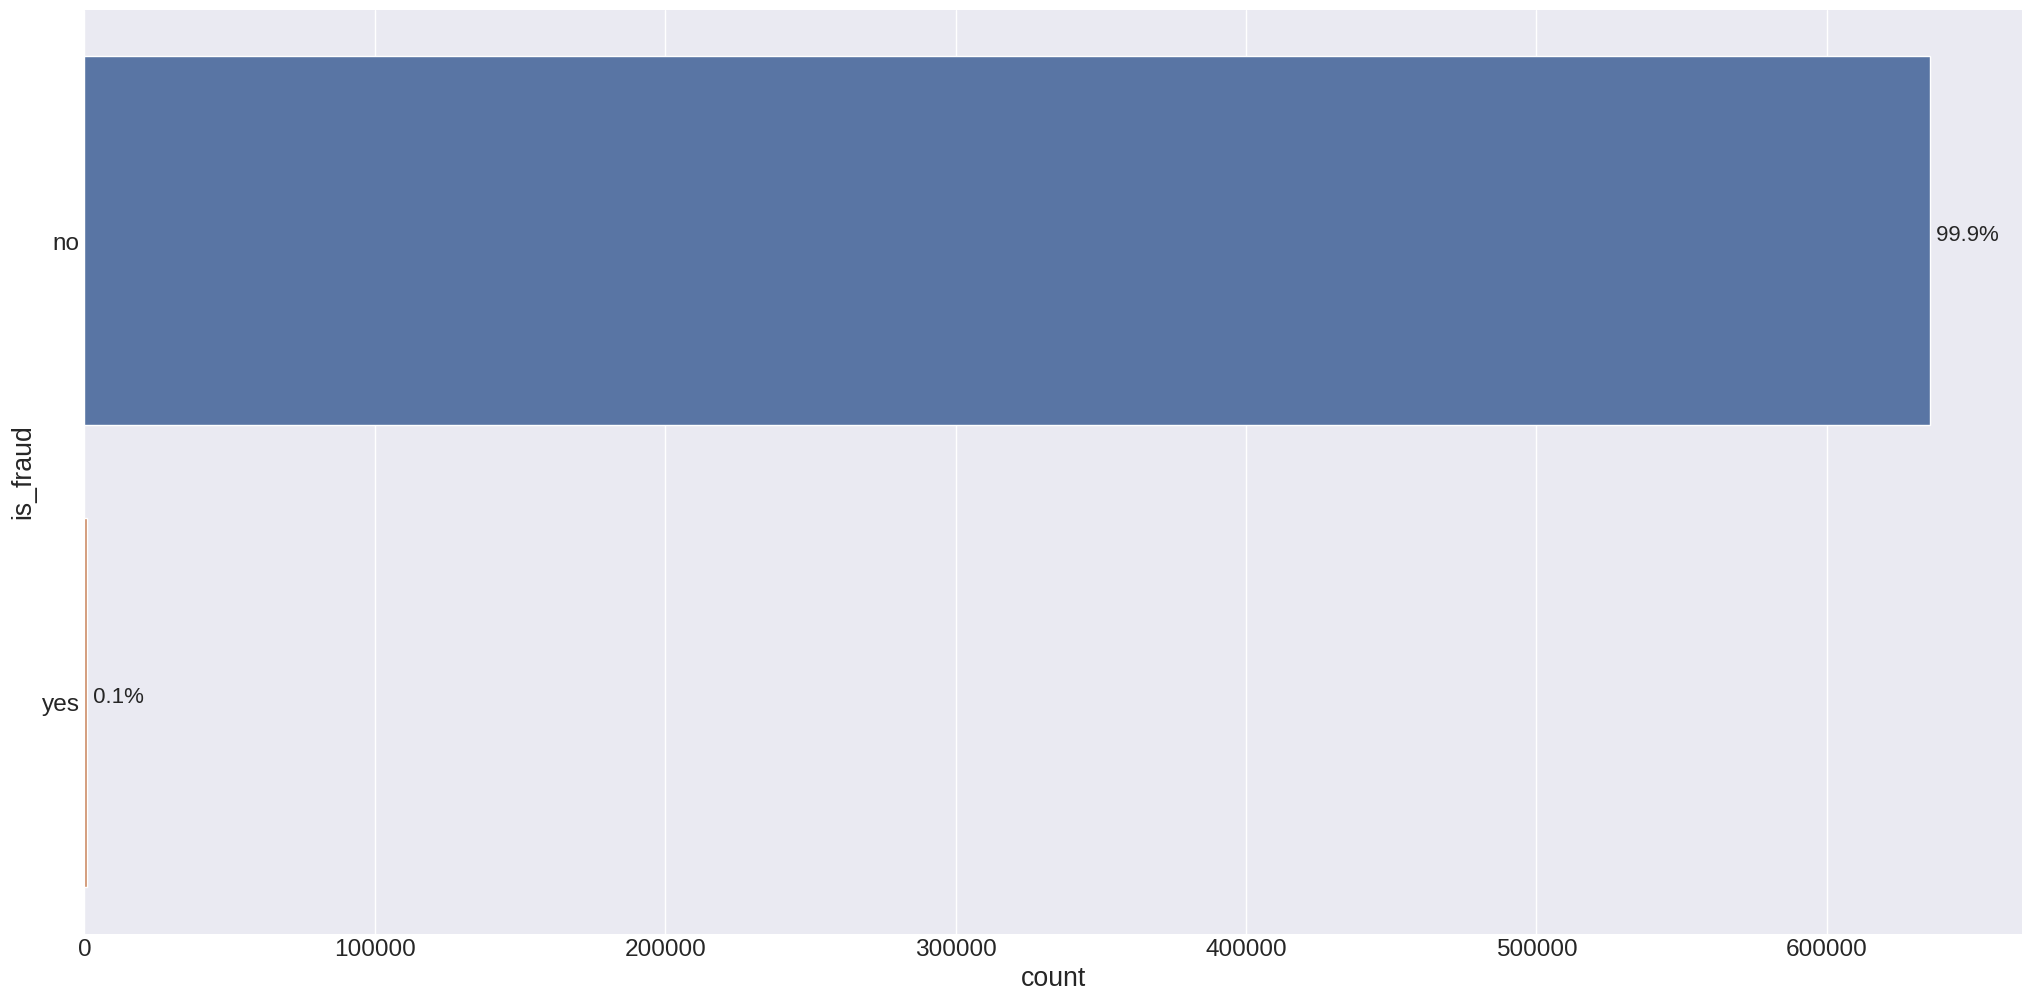

In [25]:
ax = sns.countplot(y='is_fraud', data=df4);

total = df4['is_fraud'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

# 4.1.2 Numerical Variables


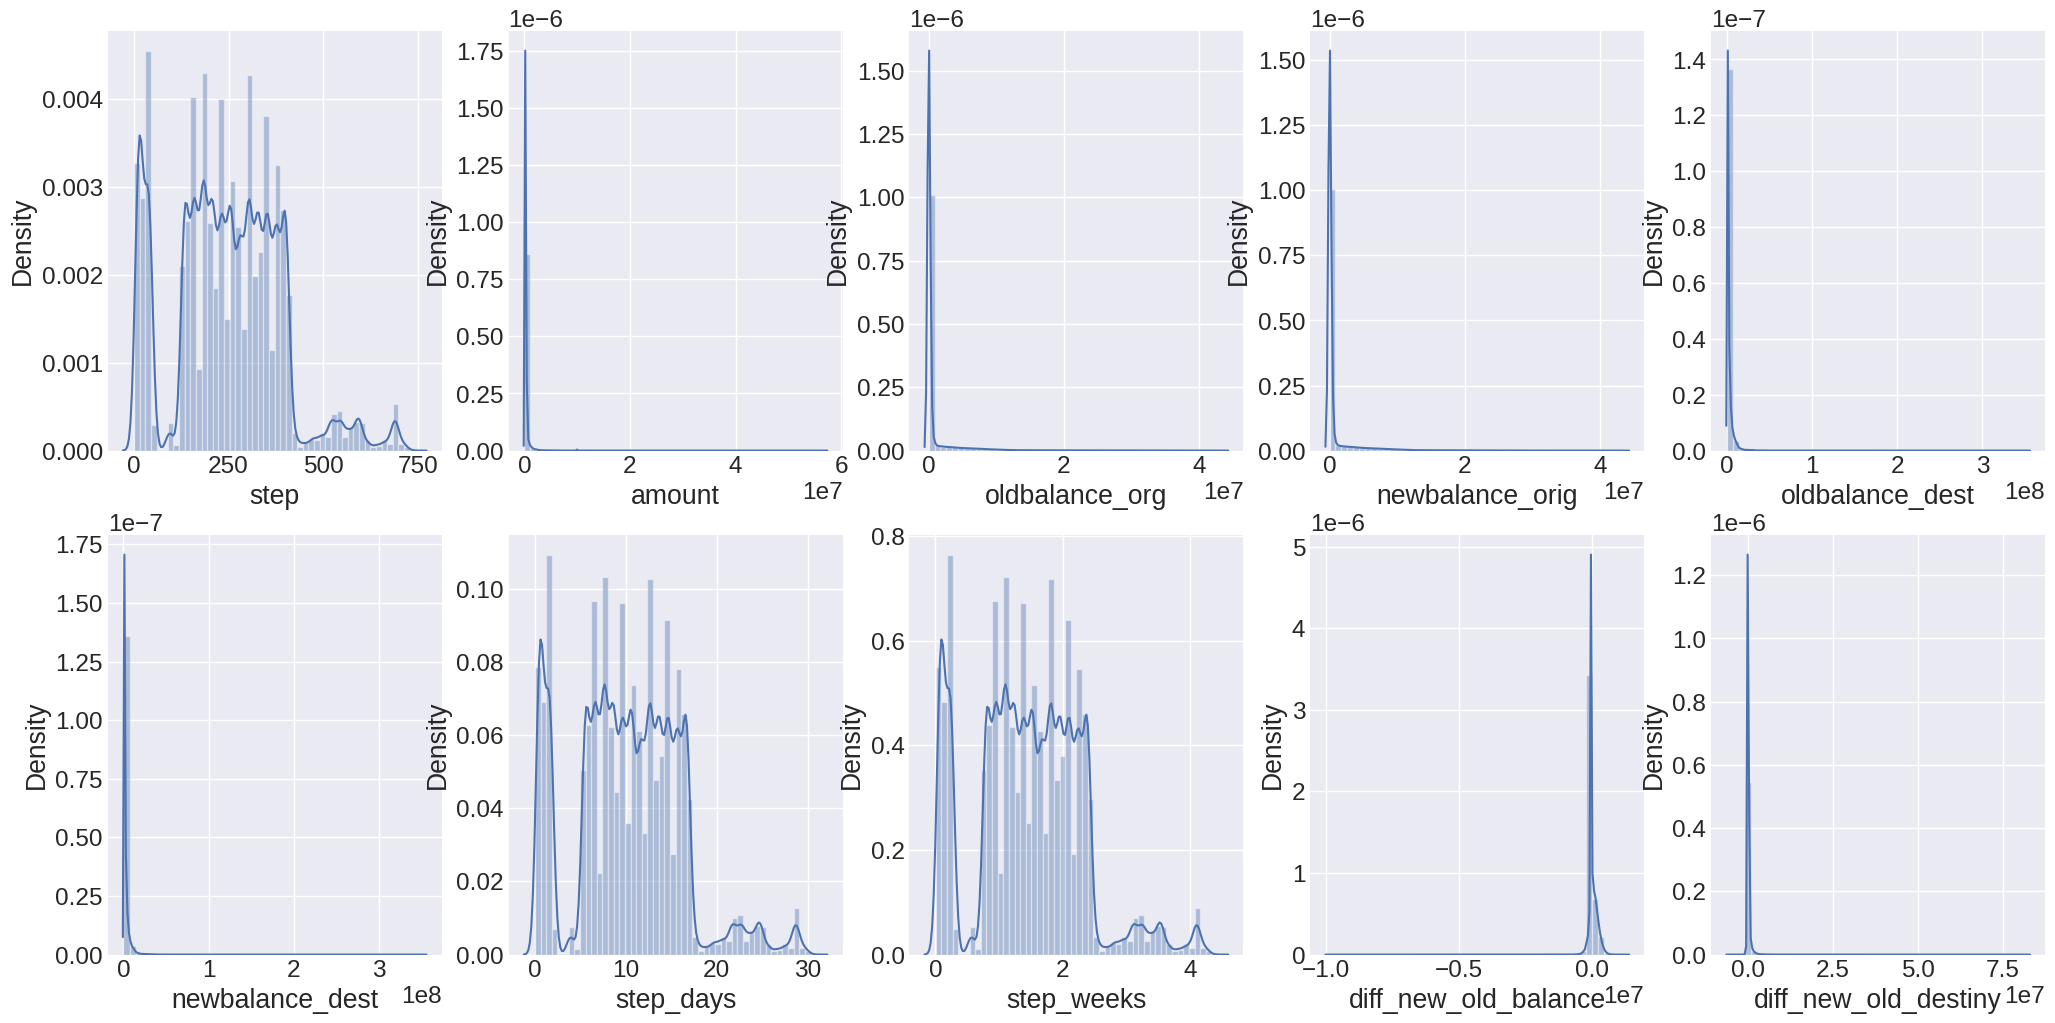

In [26]:
num_attributes = df4.select_dtypes(exclude='object')
columns = num_attributes.columns.tolist()
j = 1

for column in columns:
    plt.subplot(2, 5, j)
    sns.distplot(num_attributes[column]);
    
    j += 1

# 4.1.3 Categorical Variables


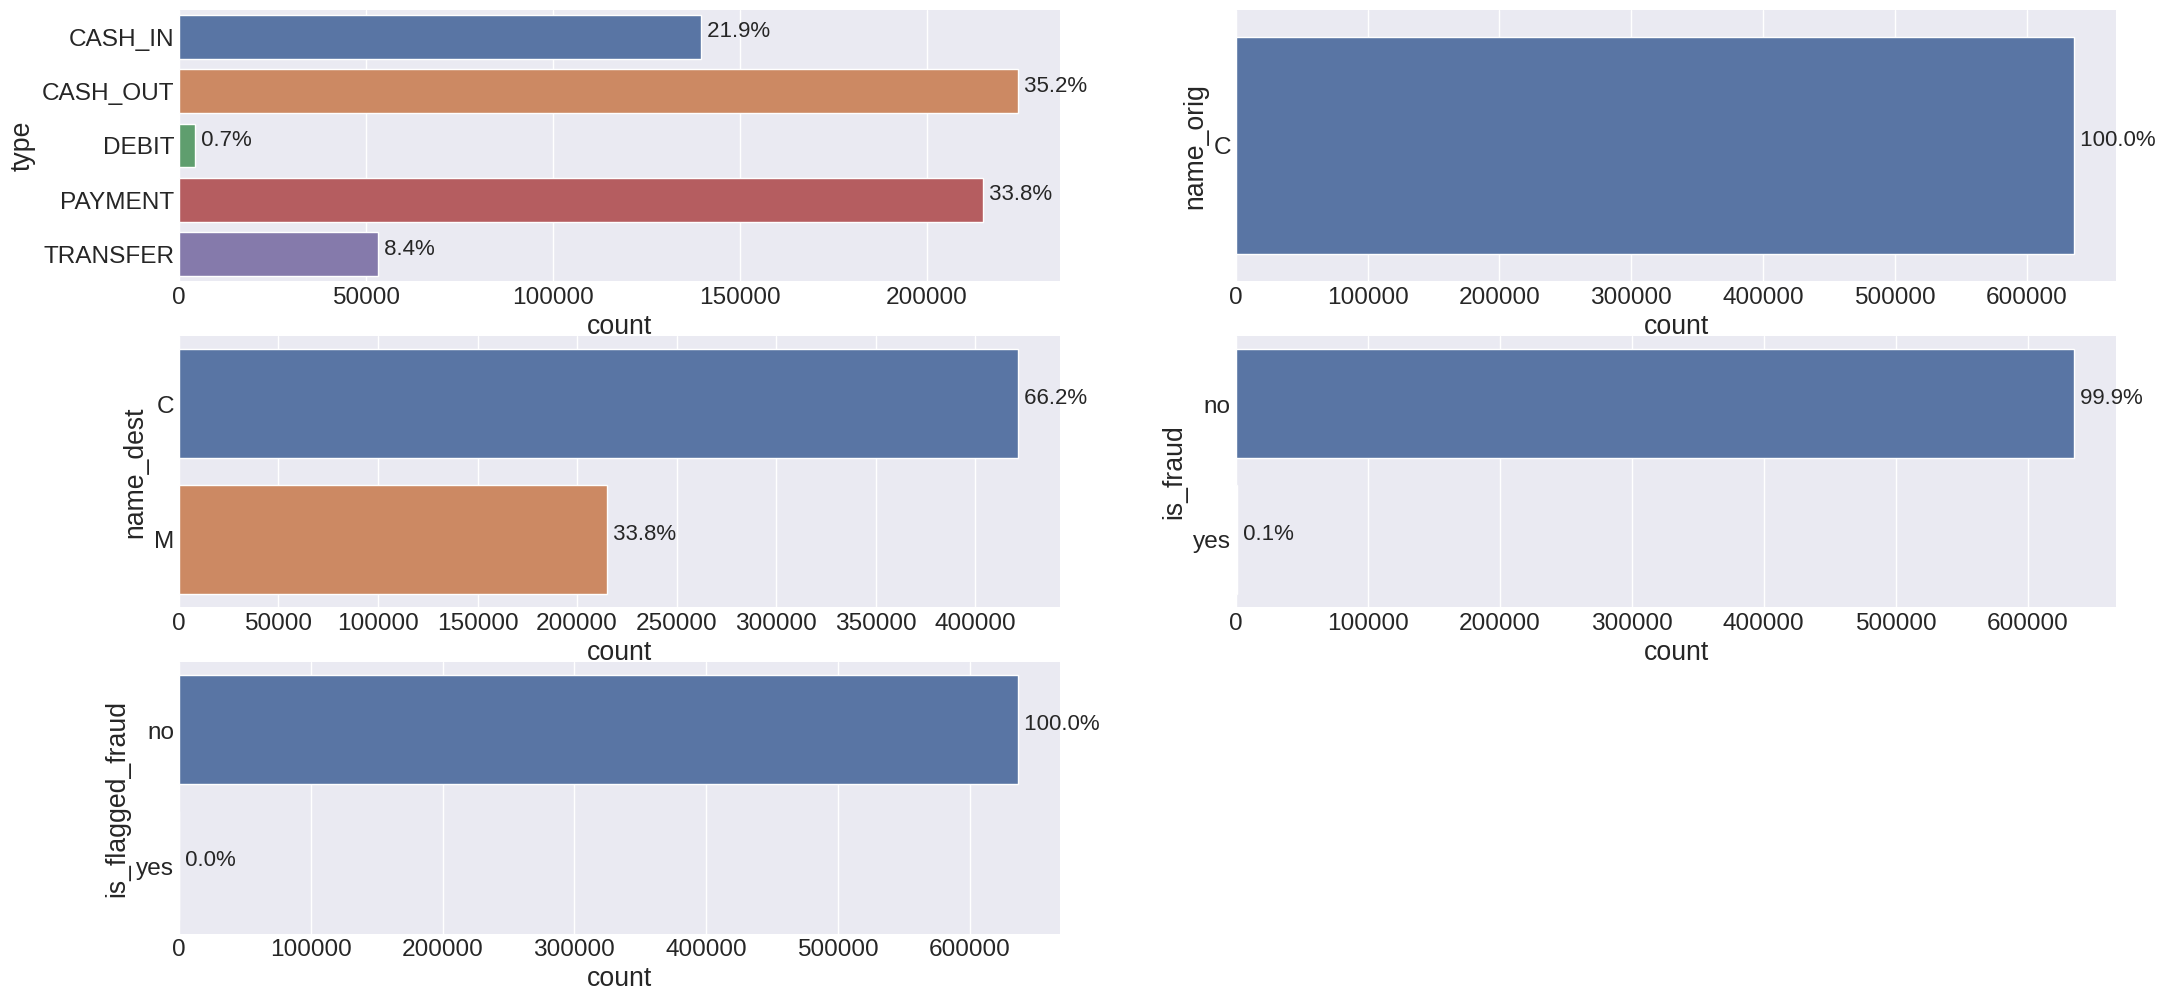

In [27]:
cat_attributes = df4.select_dtypes(include='object')
columns = cat_attributes.columns.tolist()
j = 1

for column in columns:
    plt.subplot(3, 2, j)
    ax = sns.countplot(y=column, data=cat_attributes)
    
    total = cat_attributes[column].size
    for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))
    
    j += 1

# 4.2 Multivariaty Analysis
### 4.2.1 Numerical Analysis

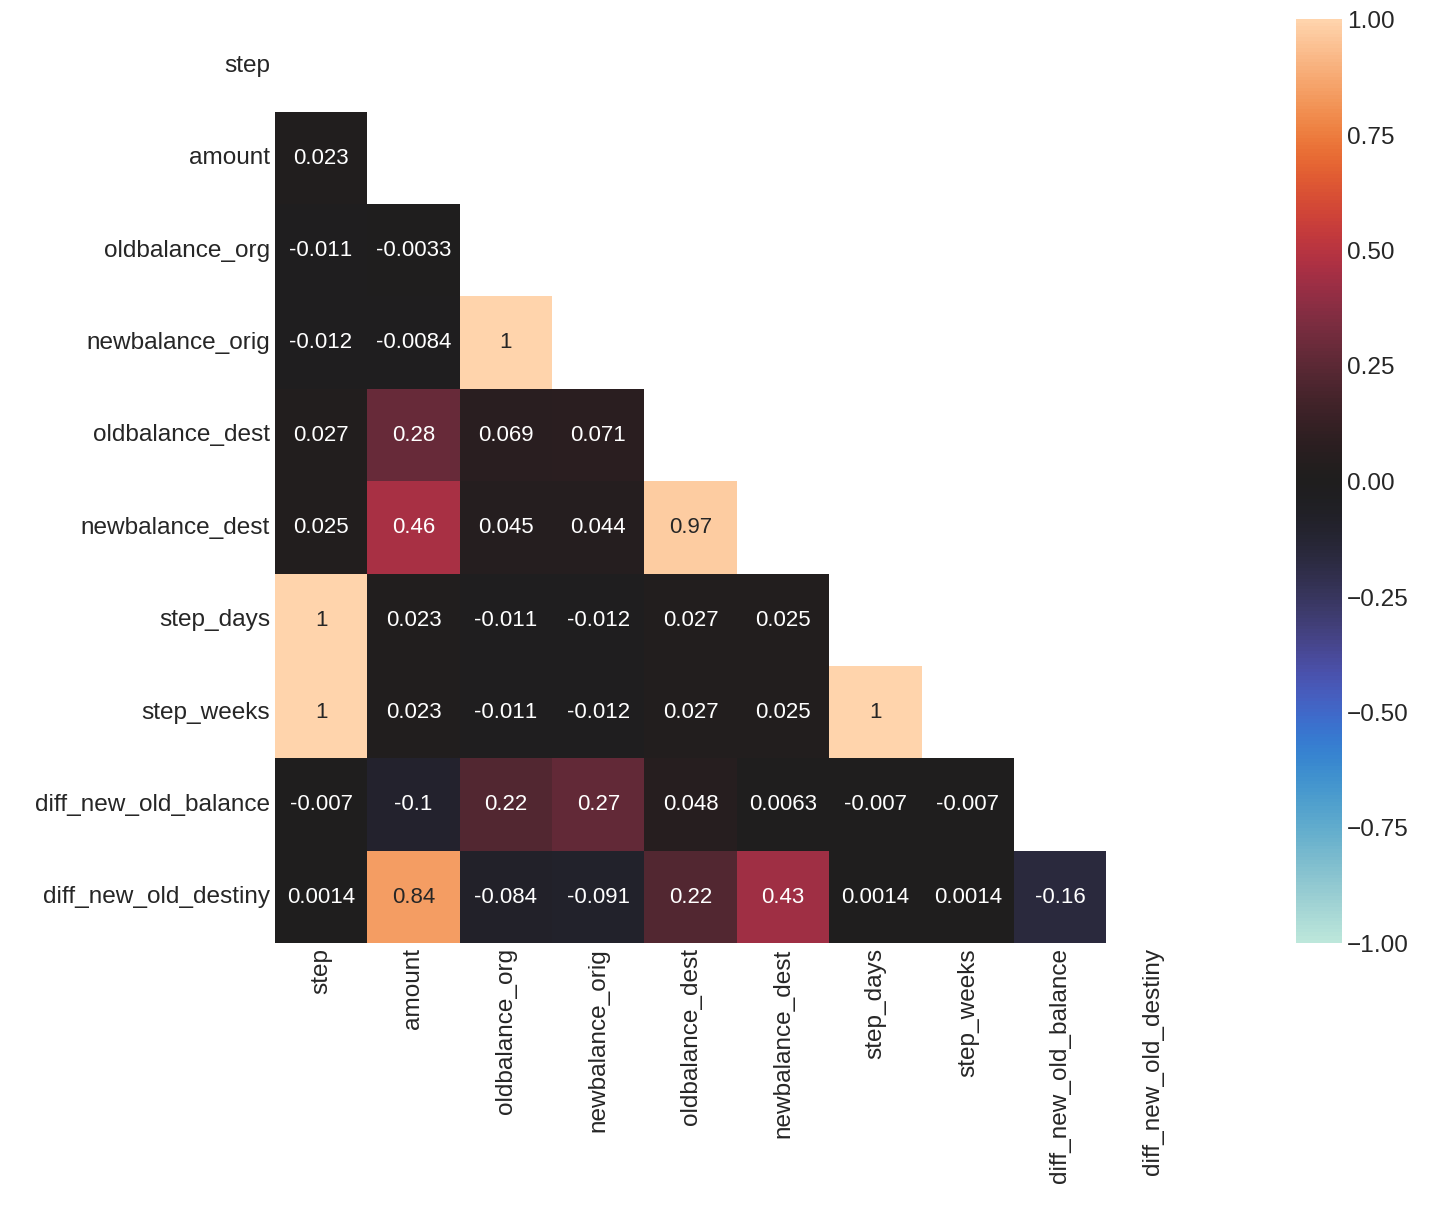

In [28]:
corr = num_attributes.corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, mask=mask, vmin=-1, center=0, vmax=1, square=True)

# 4.2.2 Categorical Variables


In [29]:
dict_corr = {}
columns = cat_attributes.columns.tolist()

for column in columns:
    dict_corr[column] = {}
    
    for column2 in columns:
        dict_corr[column][column2] = calcCramerV(cat_attributes[column], cat_attributes[column2])
        
corr = pd.DataFrame(dict_corr)

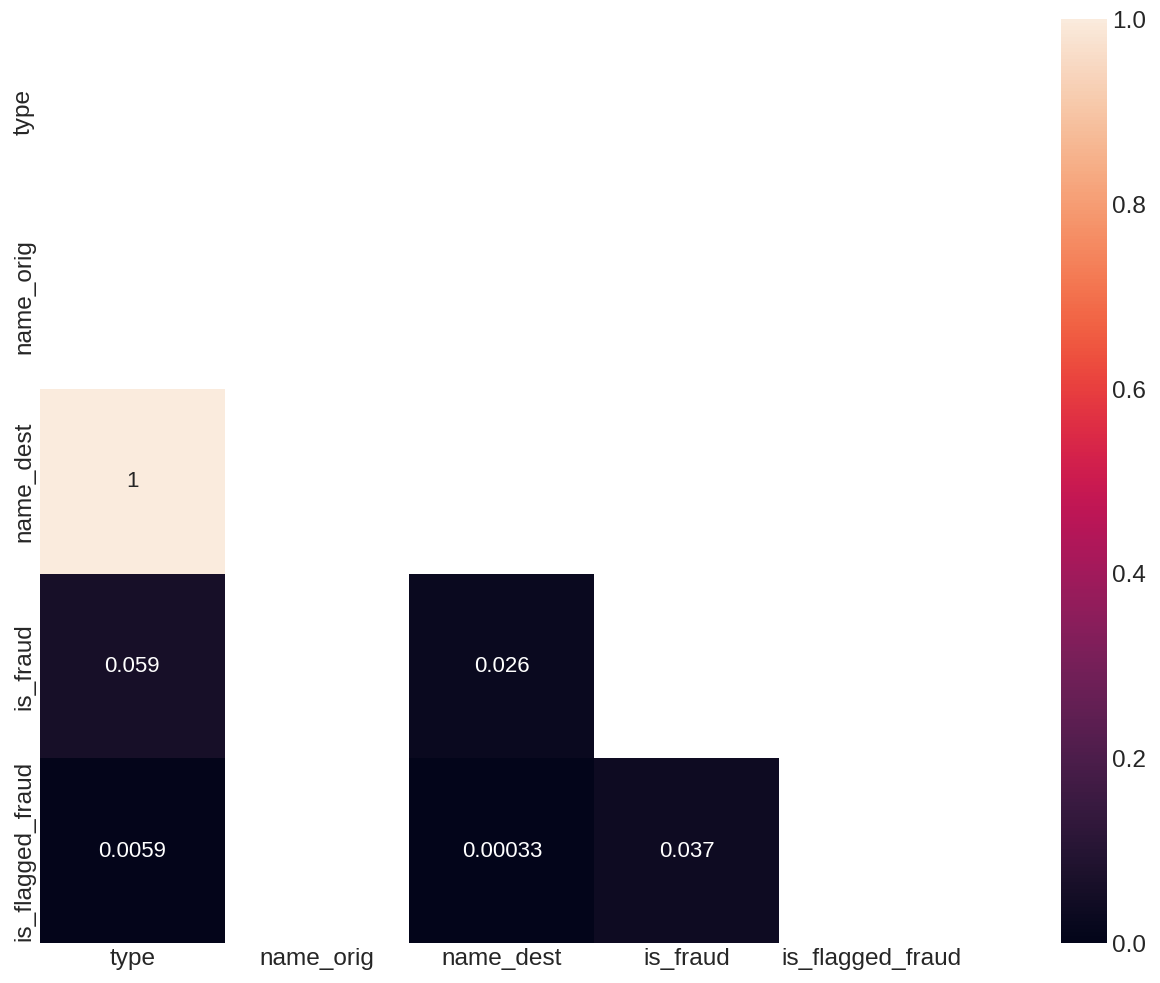

In [30]:
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, mask=mask, vmin=0, vmax=1, square=True)

# 5.0 Data Preparation


In [31]:
df5 = df4.copy()


# 5.1 Spliting into Train, Valid and Test


In [32]:
X = df5.drop(columns=['is_fraud', 'is_flagged_fraud', 'name_orig', 'name_dest', 
                      'step_weeks', 'step_days'], axis=1)
y = df5['is_fraud'].map({'yes': 1, 'no': 0})

Okay, let's break down these two lines of code clearly with examples.

This code is preparing your data for machine learning by separating it into **features (X)**, which the model will use to make predictions, and the **target variable (y)**, which is what the model will try to predict.

---

**Line 1: `X = df5.drop(columns=['is_fraud', 'is_flagged_fraud', 'name_orig', 'name_dest', 'step_weeks', 'step_days'], axis=1)`**

*   **Purpose:** To create the feature set `X`. This DataFrame will contain all the information (columns) that your model will use to learn patterns and make predictions about whether a transaction is fraudulent or not.
*   **Breakdown:**
    *   `df5`: This is your DataFrame that contains all the data after cleaning and feature engineering.
    *   `.drop(...)`: This pandas function is used to remove specified rows or columns.
    *   `columns=[...]`: This argument tells `.drop()` that we want to remove columns. The list inside the square brackets specifies which columns to remove.
        *   `'is_fraud'`: This is your actual target variable (ground truth: was it fraud or not?). You remove it from `X` because the model shouldn't know the answer beforehand when training or predicting.
        *   `'is_flagged_fraud'`: This is the rule-based flag from the simulation. It's often dropped if it's too simplistic or if you want the model to learn more complex patterns without being biased by this basic rule.
        *   `'name_orig'`, `'name_dest'`: These are the columns containing the *first letter* of the originator and destination IDs (e.g., 'C' or 'M'). These are being dropped here. This implies that either:
            *   They were not found to be useful predictive features for the final model.
            *   Their information was captured in another way (e.g., through one-hot encoding of the original 'type' column, which indirectly tells you about customer-to-customer vs. customer-to-merchant transactions if 'type' like 'TRANSFER' primarily happens between 'C's, and 'PAYMENT' between 'C' and 'M').
            *   They were created for EDA and deemed not necessary for the model itself.
        *   `'step_weeks'`, `'step_days'`: These are the time-based features you engineered (step converted to weeks and days). Dropping them suggests that either the raw `step` (which is kept) was found to be more effective, or these aggregated time features didn't add enough predictive power for the chosen model after scaling/encoding.
    *   `axis=1`: This tells `.drop()` to operate on columns (axis 0 would be rows).
*   **Result:** The DataFrame `X` will contain all the columns from `df5` **except** the six columns listed. The columns remaining in `X` at this point (before any further OneHotEncoding or Scaling that happens later in your pipeline) would be:
    *   `step` (original hourly step)
    *   `type` (original categorical: 'CASH\_IN', 'CASH\_OUT', etc.)
    *   `amount`
    *   `oldbalance_org`
    *   `newbalance_orig`
    *   `oldbalance_dest`
    *   `newbalance_dest`
    *   `diff_new_old_balance` (engineered)
    *   `diff_new_old_destiny` (engineered)
*   **Example:**
    Imagine `df5` initially looked like this (simplified):
    | step | type     | amount | name\_orig (1st letter) | is\_fraud (yes/no) | diff\_new\_old\_balance |
    | :--- | :------- | :----- | :-------------------- | :----------------- | :---------------------- |
    | 10   | CASH\_OUT | 100    | C                     | no                 | -100                    |
    | 12   | TRANSFER | 5000   | C                     | yes                | -5000                   |
    | 15   | PAYMENT  | 50     | C                     | no                 | -50                     |

    After `X = df5.drop(columns=['is_fraud', 'name_orig'], axis=1)` (just using two for this example), `X` would be:
    | step | type     | amount | diff\_new\_old\_balance |
    | :--- | :------- | :----- | :---------------------- |
    | 10   | CASH\_OUT | 100    | -100                    |
    | 12   | TRANSFER | 5000   | -5000                   |
    | 15   | PAYMENT  | 50     | -50                     |

---

**Line 2: `y = df5['is_fraud'].map({'yes': 1, 'no': 0})`**

*   **Purpose:** To create the target variable `y`. This Series (a single column) will contain the "answers" – whether each transaction was actually a fraud or not – that the model will learn to predict.
*   **Breakdown:**
    *   `df5['is_fraud']`: This selects only the `is_fraud` column from the `df5` DataFrame. At this stage (from your training notebook's Cell 243), this column contains string values 'yes' (for fraud) or 'no' (for legitimate).
    *   `.map({'yes': 1, 'no': 0})`: This function is used to transform the values in the selected column.
        *   It takes a dictionary as an argument: `{'yes': 1, 'no': 0}`.
        *   This dictionary defines the mapping: wherever it sees 'yes', it will replace it with the number `1`. Wherever it sees 'no', it will replace it with the number `0`.
*   **Result:** The Series `y` will contain `1`s for fraudulent transactions and `0`s for legitimate transactions. Machine learning models typically require numerical input for the target variable in classification tasks.
*   **Example:**
    Continuing from the `df5` example above:
    `df5['is_fraud']` was:
    | is\_fraud (yes/no) |
    | :----------------- |
    | no                 |
    | yes                |
    | no                 |

    After `y = df5['is_fraud'].map({'yes': 1, 'no': 0})`, `y` would be:
    | is\_fraud (0/1) |
    | :-------------- |
    | 0               |
    | 1               |
    | 0               |

---

**In summary:**

These lines are standard practice in preparing data for supervised machine learning:
1.  `X` is created by selecting all the relevant input features and dropping the target variable and any other columns not intended for the model.
2.  `y` is created by isolating the target variable and converting it into a numerical format (0s and 1s) suitable for training a classification model.

In [33]:
# spliting into temp and test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, stratify=y)

Okay, let's break down this line of code which is a crucial step in preparing your data for machine learning model training and evaluation.

**Line: `X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, stratify=y)`**

*   **Purpose:** To split your dataset (`X` features and `y` target labels) into two separate sets:
    1.  A **temporary set (`X_temp`, `y_temp`)**: This set will be used for further splitting into training and validation sets, and potentially for hyperparameter tuning.
    2.  A **test set (`X_test`, `y_test`)**: This set is kept completely separate and is only used at the very end to evaluate the performance of your *final, trained model* on data it has never seen before. This gives an unbiased estimate of how well your model will perform in the real world.

*   **Breakdown:**
    *   `train_test_split`: This is a function from the `sklearn.model_selection` library. Its job is to shuffle and split data.
    *   `X`: This is your DataFrame of features (input variables for the model) that you created in the previous step.
    *   `y`: This is your Series of target labels (what you want to predict, e.g., 0 for non-fraud, 1 for fraud).
    *   `test_size=.2`: This argument specifies the proportion of the dataset to allocate to the test set.
        *   `.2` means 20% of the data will be put into `X_test` and `y_test`.
        *   The remaining 80% will go into `X_temp` and `y_temp`.
    *   `stratify=y`: This is a very important argument, especially for imbalanced datasets like fraud detection.
        *   **Explanation:** It ensures that the splitting is done in such a way that the proportion of each class (fraud vs. non-fraud in your `y` variable) is approximately the same in both the temporary set (`y_temp`) and the test set (`y_test`) as it was in the original `y`.
        *   **Why it's important:** If you have very few fraud cases (e.g., 1% of your data), a random split without stratification might, by chance, put all (or very few) fraud cases into the test set, leading to unrealistic training or evaluation scenarios. Stratification prevents this by maintaining the class distribution.
    *   `X_temp, X_test, y_temp, y_test = ...`: This is how Python assigns the output of the `train_test_split` function. The function returns four datasets, and they are assigned to these four variables in order:
        1.  `X_temp`: Features for the temporary set (80% of `X`).
        2.  `X_test`: Features for the test set (20% of `X`).
        3.  `y_temp`: Target labels for the temporary set (80% of `y`).
        4.  `y_test`: Target labels for the test set (20% of `y`).

*   **Example:**
    Imagine you have 1000 transactions in `X` and `y`.
    *   `y` contains 10 fraudulent transactions (1%) and 990 legitimate ones.

    After running `train_test_split(X, y, test_size=.2, stratify=y)`:
    *   **`X_temp` and `y_temp` (Temporary Set - 80%):**
        *   `X_temp` will have features for 800 transactions.
        *   `y_temp` will have labels for these 800 transactions. Because of `stratify=y`, `y_temp` will have approximately 8 fraudulent transactions (1% of 800) and 792 legitimate ones.
    *   **`X_test` and `y_test` (Test Set - 20%):**
        *   `X_test` will have features for 200 transactions.
        *   `y_test` will have labels for these 200 transactions. Because of `stratify=y`, `y_test` will have approximately 2 fraudulent transactions (1% of 200) and 198 legitimate ones.

**In summary:**

This line splits your data into a larger temporary set (80%) and a smaller, held-out test set (20%). The split is done randomly but in a stratified way to ensure that both sets have a similar percentage of fraud and non-fraud cases as your original dataset. The temporary set will be used for training and validating the model during development, while the test set is reserved for a final, unbiased performance check.

In [34]:
# spliting into train and valid
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=.2, stratify=y_temp)

You're asking a great and fundamental question in machine learning! The validation set plays a crucial role in building robust models that generalize well to new, unseen data.

Here's why we often need a validation set, not just train and test sets, explained with an example:

**The Problem with Using Only Train and Test Sets (Especially for Tuning):**

Imagine you're trying to find the best settings (hyperparameters) for your fraud detection model.

1.  **Scenario: Only Train and Test**
    *   You split your data into a training set (e.g., 80%) and a test set (e.g., 20%).
    *   **Tuning Process:**
        *   You pick a set of hyperparameters (e.g., `learning_rate=0.1`, `max_depth=3`).
        *   You train your model on the **training set** using these hyperparameters.
        *   You evaluate its performance on the **test set**. Let's say you get an F1-score of 0.70.
        *   You try another set of hyperparameters (e.g., `learning_rate=0.05`, `max_depth=5`).
        *   You train again on the **training set**.
        *   You evaluate again on the **test set**. Now you get an F1-score of 0.75.
        *   You repeat this many times, trying different hyperparameter combinations. Each time, you choose the hyperparameters that give the best score on the **test set**.

2.  **The Issue: Information Leakage and Overfitting to the Test Set**
    *   By repeatedly evaluating different model configurations (due to different hyperparameters) on the *same test set*, you are indirectly "leaking" information from the test set into your model selection process.
    *   Your choice of "best" hyperparameters becomes optimized for *that specific test set*. The model might learn patterns or noise that are peculiar to your test set but not representative of new, real-world data.
    *   When you finally report the performance of your "best" model (chosen based on the test set), that performance score might be **overly optimistic**. The model might appear to perform well on *this* test set, but it could perform poorly on genuinely unseen data because it has, in a way, "seen" the test set multiple times during the tuning phase.
    *   This is a form of **overfitting**, but instead of overfitting to the training data, you're overfitting your *hyperparameter choices* to the test data.

**How a Validation Set Solves This:**

1.  **The Three-Way Split:**
    *   **Training Set (e.g., 60%):** Used *only* to train the model (learn the parameters like weights in a neural network or splits in a decision tree).
    *   **Validation Set (e.g., 20%):** Used *only* to select the best hyperparameters and make other model development decisions (like feature selection or early stopping). The model *never trains* on this data.
    *   **Test Set (e.g., 20%):** Used *only once* at the very end to get an unbiased estimate of the final chosen model's performance on completely unseen data.

2.  **Tuning Process with a Validation Set:**
    *   You pick a set of hyperparameters.
    *   You train your model on the **training set**.
    *   You evaluate its performance on the **validation set**.
    *   You repeat this with different hyperparameter combinations.
    *   You choose the hyperparameters that give the best score on the **validation set**.
    *   Once you've chosen your best hyperparameters (and thus your best model configuration), you then train this final model configuration on the *combined training and validation data* (or just the training data, practices vary).
    *   Finally, you evaluate this trained model *once* on the **test set**. This score is your most reliable estimate of real-world performance.

**Example: Fraud Detection**

*   **Data:** 1000 transactions (10 fraud, 990 non-fraud).
*   **Split:**
    *   Train: 600 (6 fraud)
    *   Validation: 200 (2 fraud)
    *   Test: 200 (2 fraud)

*   **Without Validation Set (Train/Test only):**
    1.  **Try 1:** Model A (hyperparams A) trained on 800 transactions. Tested on 200 test transactions. F1-score = 0.6.
    2.  **Try 2:** Model B (hyperparams B) trained on 800 transactions. Tested on the *same* 200 test transactions. F1-score = 0.7.
    3.  You pick Model B because it did better on the test set.
    *   **Problem:** Model B might just be good at *those specific 200 test transactions*. You don't know if it's genuinely better.

*   **With Validation Set:**
    1.  **Try 1 (Hyperparams A):**
        *   Train Model A on the 600 **training** transactions.
        *   Evaluate on the 200 **validation** transactions. F1-score = 0.5.
    2.  **Try 2 (Hyperparams B):**
        *   Train Model B on the 600 **training** transactions.
        *   Evaluate on the 200 **validation** transactions. F1-score = 0.65.
    3.  **Try 3 (Hyperparams C):**
        *   Train Model C on the 600 **training** transactions.
        *   Evaluate on the 200 **validation** transactions. F1-score = 0.6.
    4.  You choose Hyperparams B because they performed best on the **validation set**.
    5.  Now, you take the model architecture with Hyperparams B and train it on all 800 transactions (Train + Validation).
    6.  You then evaluate this final model *once* on the 200 **test** transactions. Let's say the F1-score is 0.62. This 0.62 is a more trustworthy measure of its expected performance.

**Why `X_temp` and `y_temp` in your notebook?**

The code `X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, stratify=y)` creates the initial split.
The *next* line in your notebook is:
`X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=.2, stratify=y_temp)`

This second line takes the `X_temp` and `y_temp` (which was 80% of the original data) and splits *that* into:
*   `X_train`, `y_train` (80% of `X_temp`, so 80% of 80% = 64% of original data)
*   `X_valid`, `y_valid` (20% of `X_temp`, so 20% of 80% = 16% of original data)

So, your overall split becomes roughly:
*   Train: 64%
*   Validation: 16%
*   Test: 20%

This is exactly the three-way split strategy!

**In summary:**

The **validation set** acts as an unbiased judge during the model development and hyperparameter tuning phase. It helps you make decisions about your model's configuration without "contaminating" the final test set. The **test set** is then used for a final, honest assessment of how well the *chosen* model is likely to perform on new data. This leads to more reliable and generalizable models.

Okay, here's a clear and simple explanation of why we need a validation dataset, not just train and test sets, with an example.

**The Problem with Only Train and Test Sets (The "Peeking" Problem):**

Imagine you're a student preparing for a big final exam.

1.  **Train Set:** This is like your textbook and homework problems. You use these to study and learn the material.
2.  **Test Set:** This is like the *final exam*. It's supposed to be a surprise, and your score on it tells you how well you've *actually* learned.

**Now, imagine you're also trying to figure out the best way to study (these are your "hyperparameters" or model settings):**

*   Should you study 2 hours a day or 4 hours?
*   Should you focus on memorizing or understanding concepts?
*   Should you use flashcards or practice tests?

**If you only have your textbook (Train Set) and the Final Exam (Test Set):**

1.  You try studying method A (e.g., 2 hours, memorizing).
2.  You "practice" by looking at the final exam questions (Test Set) to see how well method A prepared you. You get a score.
3.  You try studying method B (e.g., 4 hours, understanding concepts).
4.  You "practice" again by looking at the *same* final exam questions (Test Set). You get a different score.
5.  You keep doing this, adjusting your study method based on how well you do on the *same* final exam questions.

**The "Peeking" Problem:**
You've essentially "peeked" at the final exam multiple times while trying to find the best study method. The study method you finally choose might be great for *that specific exam*, but not necessarily for other exams or real-world problems because you've tailored it too much to the questions you've already seen. Your score on *that* final exam might be artificially high.

**How a Validation Set Helps (The "Practice Exam"):**

To avoid peeking at the final exam, you introduce a **Validation Set**. This is like a **practice exam**.

1.  **Train Set (Textbook/Homework):** You study here.
2.  **Validation Set (Practice Exam):** You use this to:
    *   Try out different study methods (hyperparameters).
    *   See which study method gives you the best score on the *practice exam*.
    *   You can take the practice exam many times with different study methods.
3.  **Test Set (Final Exam):** Once you've used the practice exam to find your *best study method*, you use that method to prepare. Then, you take the final exam *only once*. This score is a true, unbiased measure of your learning.

**In Machine Learning Terms:**

*   **Train Set:** Data used to teach the model.
*   **Validation Set:** Data used to:
    *   Tune hyperparameters (like the model's internal settings).
    *   Choose between different models (e.g., should I use Logistic Regression or a Random Forest?).
    *   Decide when to stop training (early stopping).
    The model's performance on the validation set guides these decisions.
*   **Test Set:** Data kept completely separate. Used *only once* at the very end to get a final, honest score of how well your chosen, tuned model performs on new, unseen data.

**Example: Fraud Detection Model**

*   **You want to find the best `max_depth` (a hyperparameter) for your decision tree model.**
*   **Data:** 1000 transactions.
*   **Split:**
    *   Train: 600 transactions
    *   Validation: 200 transactions
    *   Test: 200 transactions

*   **Process with Validation Set:**
    1.  **Try `max_depth = 3`:**
        *   Train the model on the 600 **Train** transactions.
        *   Evaluate on the 200 **Validation** transactions. Get F1-score = 0.70.
    2.  **Try `max_depth = 5`:**
        *   Train the model on the 600 **Train** transactions.
        *   Evaluate on the 200 **Validation** transactions. Get F1-score = 0.75.
    3.  **Try `max_depth = 7`:**
        *   Train the model on the 600 **Train** transactions.
        *   Evaluate on the 200 **Validation** transactions. Get F1-score = 0.72.
    4.  **Decision:** `max_depth = 5` looks best based on the **Validation set**.
    5.  **Final Step:** Train a model with `max_depth = 5` on the combined Train + Validation data (or just Train). Then, evaluate this final model *once* on the 200 **Test** transactions. This gives you your reliable performance estimate.

**Why this is better:**
The test set remained untouched during your hyperparameter tuning. So, its result is a more trustworthy indicator of how your model will do on brand-new data it has never seen in any form during its development.

**In short:** The validation set is your "practice ground" for making model development decisions (like choosing settings). The test set is the "final, official evaluation" on truly unseen data. This prevents you from making decisions that only look good on your test data but don't generalize well.

# 5.2 One Hot Encoder


In [35]:
ohe = OneHotEncoder(cols=['type'], use_cat_names=True)

X_train = ohe.fit_transform(X_train)
X_valid = ohe.transform(X_valid)

X_temp = ohe.fit_transform(X_temp)
X_test = ohe.transform(X_test)

Okay, let's dive into One-Hot Encoding and then explain how it's applied in this specific code block.

---

**What is One-Hot Encoding? (Simple Explanation with Example)**

Imagine you have a feature in your dataset called "Favorite Color," and it can have values like "Red," "Blue," or "Green." Machine learning models usually work with numbers, not text. So, we need a way to convert these color names into a numerical format.

**One-Hot Encoding** is a popular technique to do this for **categorical features** (features that represent categories or labels).

Here's how it works:

1.  **Identify Unique Categories:** First, find all the unique values (categories) in your "Favorite Color" column. In our example, these are "Red," "Blue," and "Green."

2.  **Create New Binary Columns:** For each unique category, you create a new column.
    *   A column named "Favorite Color\_Red"
    *   A column named "Favorite Color\_Blue"
    *   A column named "Favorite Color\_Green"

3.  **Populate with 0s and 1s:** For each original row (each person's favorite color):
    *   If the person's favorite color was "Red," the "Favorite Color\_Red" column gets a `1`, and the "Favorite Color\_Blue" and "Favorite Color\_Green" columns get a `0`.
    *   If the color was "Blue," "Favorite Color\_Blue" gets a `1`, and the others get `0`.
    *   And so on.

**Example:**

**Original Data:**

| Person | Favorite Color |
| :----- | :------------- |
| Alice  | Red            |
| Bob    | Blue           |
| Carol  | Green          |
| Dave   | Red            |

**After One-Hot Encoding:**

| Person | Favorite Color\_Red | Favorite Color\_Blue | Favorite Color\_Green |
| :----- | :------------------ | :------------------- | :-------------------- |
| Alice  | 1                   | 0                    | 0                     |
| Bob    | 0                   | 1                    | 0                     |
| Carol  | 0                   | 0                    | 1                     |
| Dave   | 1                   | 0                    | 0                     |

**Why "One-Hot"?**
Because for each row, only *one* of the newly created categorical columns will be "hot" (have a value of 1), while all others will be "cold" (have a value of 0).

**Advantages:**
*   It converts categorical data into a numerical format that models can understand.
*   It doesn't impose an artificial order on the categories (unlike, say, mapping Red=1, Blue=2, Green=3, which might imply Blue is "greater" than Red).

**Disadvantage:**
*   If you have many unique categories in a column, it can create a lot of new columns (this is called the "curse of dimensionality").

---

**Explanation of the Code Block:**

```python
# 5.2 One Hot Encoder
ohe = OneHotEncoder(cols=['type'], use_cat_names=True)

X_train = ohe.fit_transform(X_train)
X_valid = ohe.transform(X_valid)

X_temp = ohe.fit_transform(X_temp) # This line has a subtle but important implication
X_test = ohe.transform(X_test)
```

*   **`ohe = OneHotEncoder(cols=['type'], use_cat_names=True)`**
    *   **Purpose:** Initializes the One-Hot Encoder.
    *   **Explanation:**
        *   `OneHotEncoder`: This is likely an encoder from the `category_encoders` library (based on your earlier imports). Scikit-learn also has one, but `category_encoders` often has more convenient options.
        *   `cols=['type']`: This tells the encoder to *only* apply one-hot encoding to the column named `'type'` in the DataFrames it processes. Other columns will be passed through unchanged.
        *   `use_cat_names=True`: This is a useful parameter. When new columns are created, it will name them in a way that includes the original column name and the category value. For example, if 'type' has a category 'CASH\_IN', a new column `type_CASH_IN` will be created.

*   **`X_train = ohe.fit_transform(X_train)`**
    *   **Purpose:** Learns the categories from the `type` column in `X_train` and then transforms `X_train`.
    *   **Explanation:**
        *   `.fit_transform()`: This is a two-step process done in one go:
            1.  **`fit()`**: The encoder looks at the `'type'` column in your `X_train` DataFrame. It identifies all the unique transaction types present (e.g., 'CASH\_OUT', 'PAYMENT', 'CASH\_IN', 'TRANSFER', 'DEBIT'). It "learns" these categories.
            2.  **`transform()`**: It then applies the one-hot encoding based on these learned categories. The original `'type'` column in `X_train` is replaced by several new binary columns (e.g., `type_CASH_OUT`, `type_PAYMENT`, etc.).
        *   `X_train = ...`: The result (the `X_train` DataFrame with the 'type' column one-hot encoded) is assigned back to `X_train`.
    *   **Example (Conceptual):**
        If `X_train` had a 'type' column like:
        | step | type     | amount | ... |
        | :--- | :------- | :----- | :-- |
        | 10   | CASH\_OUT | 100    | ... |
        | 12   | TRANSFER | 5000   | ... |

        After `ohe.fit_transform(X_train)`, `X_train` might look like:
        | step | amount | ... | type\_CASH\_OUT | type\_TRANSFER | type\_PAYMENT | ... (other type columns) |
        | :--- | :----- | :-- | :------------- | :-------------- | :------------- | :----------------------- |
        | 10   | 100    | ... | 1              | 0               | 0              | ...                      |
        | 12   | 5000   | ... | 0              | 1               | 0              | ...                      |
        (The original 'type' column is usually dropped by the encoder).

*   **`X_valid = ohe.transform(X_valid)`**
    *   **Purpose:** Transforms the `X_valid` (validation set) using the categories already learned from `X_train`.
    *   **Explanation:**
        *   `.transform()`: **Crucially, we only use `.transform()` here, not `.fit_transform()`.**
        *   The encoder `ohe` already "knows" the categories from `X_train`. We apply the *same* transformation to `X_valid`.
        *   If `X_valid` contains a transaction type in its `'type'` column that was *not* seen in `X_train`, the encoder will handle it (e.g., by creating all zeros for the OHE columns related to 'type' for that row, or based on a `handle_unknown` parameter if set during `OneHotEncoder` initialization). This prevents data leakage from the validation set into the "fitting" process.
        *   `X_valid = ...`: The transformed `X_valid` is assigned back.

*   **`X_temp = ohe.fit_transform(X_temp)`**
    *   **Purpose:** This line re-fits the *same* `ohe` object on `X_temp` and then transforms `X_temp`.
    *   **Explanation & Implication:**
        *   `X_temp` is the dataset from which `X_train` and `X_valid` were derived. It contains all the data except the test set.
        *   By calling `ohe.fit_transform(X_temp)`, you are **re-fitting** the encoder. This means `ohe` will now learn the unique categories from the `'type'` column of the entire `X_temp` dataset.
        *   This is a common practice if you intend to use `X_temp` (and the `ohe` fitted on it) for final model training (after hyperparameter tuning) or for creating consistent features for the `X_test` set.
        *   The categories learned from `X_temp` should ideally be the same as or a superset of those learned from just `X_train`.

*   **`X_test = ohe.transform(X_test)`**
    *   **Purpose:** Transforms the `X_test` (test set) using the categories now learned from `X_temp`.
    *   **Explanation:**
        *   `.transform()`: Again, only transform. The `ohe` object now knows the categories based on the full `X_temp` dataset.
        *   This ensures that the `X_test` set is processed in exactly the same way (using the same learned categories for 'type') as the `X_temp` data that will likely be used for the final model training.

**In Summary:**

1.  An `OneHotEncoder` (`ohe`) is set up to specifically transform the `'type'` column.
2.  It's first fit on `X_train` to learn the transaction types and then transforms `X_train`.
3.  The same learned transformation (without re-fitting) is applied to `X_valid`. This is good practice to avoid data leakage during the initial train/validation splitting and evaluation.
4.  Then, the **same `ohe` object is re-fit on `X_temp`** (which is the combination of the original data that `X_train` and `X_valid` came from). This ensures the encoder knows all categories present in the data that will be used for training the model selected after hyperparameter tuning and for transforming the test set consistently.
5.  Finally, this `ohe` (now fitted on `X_temp`) is used to transform `X_test`.

This sequence ensures that the categorical `'type'` feature is converted into a numerical format suitable for the machine learning models, and that the training, validation, and test sets are processed consistently with respect to the categories learned for one-hot encoding. The re-fitting on `X_temp` before transforming `X_test` is a key step for final model training and evaluation consistency.

# 5.3 Rescaling


In [36]:
num_columns = ['amount', 'oldbalance_org', 'newbalance_orig', 'oldbalance_dest', 'newbalance_dest',
               'diff_new_old_balance', 'diff_new_old_destiny']
mm = MinMaxScaler()
X_params = X_temp.copy()

X_train[num_columns] = mm.fit_transform(X_train[num_columns])
X_valid[num_columns] = mm.transform(X_valid[num_columns])

X_params[num_columns] = mm.fit_transform(X_temp[num_columns])
X_test[num_columns] = mm.transform(X_test[num_columns])

Okay, let's break down this "5.3 Rescaling" section, explaining `MinMaxScaler` and then the code.

---

**What is Rescaling and MinMaxScaler? (Simple Explanation with Example)**

**Why Rescale?**
Machine learning algorithms, especially those that use distance calculations (like K-Nearest Neighbors, Support Vector Machines) or rely on gradients (like neural networks, logistic regression with gradient descent), can be sensitive to the scale of input features.

*   If one feature has a very large range of values (e.g., `amount` from 0 to 1,000,000) and another has a small range (e.g., `number_of_prior_transactions_today` from 0 to 10), the feature with the larger range might dominate the calculations, even if the smaller-range feature is just as important.
*   Rescaling brings all numerical features to a similar scale, preventing this dominance and often leading to better model performance and faster training.

**MinMaxScaler**
This is a common rescaling technique. It transforms each feature by scaling its values to a specific range, most commonly **between 0 and 1**.

**How it works:**
For each value `x` in a column, `MinMaxScaler` calculates the scaled value `x_scaled` using the formula:

`x_scaled = (x - min_value_in_column) / (max_value_in_column - min_value_in_column)`

*   The smallest value in the column will become 0.
*   The largest value in the column will become 1.
*   All other values will be proportionally scaled between 0 and 1.

**Example:**

**Original 'Age' Column:**

| Age |
| :-- |
| 20  |
| 30  |
| 40  |
| 50  |

*   `min_value_in_column` = 20
*   `max_value_in_column` = 50
*   `range` = 50 - 20 = 30

**After MinMaxScaler:**

| Age (Original) | Calculation                      | Age (Scaled) |
| :------------- | :------------------------------- | :----------- |
| 20             | (20 - 20) / 30                   | 0.0          |
| 30             | (30 - 20) / 30 = 10 / 30         | 0.33         |
| 40             | (40 - 20) / 30 = 20 / 30         | 0.67         |
| 50             | (50 - 20) / 30 = 30 / 30         | 1.0          |

Now, the 'Age' feature is on a 0-1 scale.

---

**Explanation of the Code Block:**

```python
# 5.3 Rescaling
num_columns = ['amount', 'oldbalance_org', 'newbalance_orig', 'oldbalance_dest', 'newbalance_dest',
               'diff_new_old_balance', 'diff_new_old_destiny']
mm = MinMaxScaler()
X_params = X_temp.copy() # X_temp here is after One-Hot Encoding from the previous step

# --- Scaling for initial Train/Validation ---
X_train[num_columns] = mm.fit_transform(X_train[num_columns])
X_valid[num_columns] = mm.transform(X_valid[num_columns])

# --- Re-fitting scaler on X_temp (includes train+valid data) for final Test set scaling ---
X_params[num_columns] = mm.fit_transform(X_temp[num_columns]) # X_temp used for fitting here
X_test[num_columns] = mm.transform(X_test[num_columns])
```

*   **`num_columns = [...]`**
    *   **Purpose:** Defines a list of column names that are numerical and need to be rescaled.
    *   **Explanation:** These are likely your original numerical features (`amount`, balances) and the numerical features you engineered (`diff_...` columns). The `step` column and the one-hot encoded `type_*` columns are typically not included in this list for min-max scaling (OHE columns are already 0/1, and `step` might be treated differently or not scaled).

*   **`mm = MinMaxScaler()`**
    *   **Purpose:** Initializes the `MinMaxScaler` object.
    *   **Explanation:** This creates an instance of the scaler. At this point, it hasn't learned anything about your data yet.

*   **`X_params = X_temp.copy()`**
    *   **Purpose:** Creates a copy of `X_temp`.
    *   **Explanation:** `X_temp` at this stage is the version that has undergone One-Hot Encoding of the 'type' column (from the previous "5.2 One Hot Encoder" step). `X_params` will be used later for hyperparameter tuning, and it's good practice to work on a copy to preserve `X_temp` if needed.

*   **`X_train[num_columns] = mm.fit_transform(X_train[num_columns])`**
    *   **Purpose:** Fits the scaler on the numerical columns of the **training data** and then scales these columns in `X_train`.
    *   **Explanation:**
        *   `X_train[num_columns]`: Selects only the specified numerical columns from the `X_train` DataFrame.
        *   `mm.fit_transform(...)`: This is a two-step process:
            1.  **`fit()`**: The `mm` scaler looks at these selected numerical columns *only in `X_train`*. For each of these columns, it calculates the minimum and maximum values. These learned min/max values are stored within the `mm` object.
            2.  **`transform()`**: It then uses these learned min/max values to scale the data in `X_train[num_columns]`, converting them to the 0-1 range.
        *   `X_train[num_columns] = ...`: The rescaled numerical columns are put back into `X_train`, replacing the original unscaled versions.
    *   **Example:** If `X_train['amount']` had values [100, 200, 1000], `mm` would learn min=100, max=1000 for this column from `X_train`. It would then transform these to [0, 0.11, 1.0].

*   **`X_valid[num_columns] = mm.transform(X_valid[num_columns])`**
    *   **Purpose:** Scales the numerical columns of the **validation data** using the parameters (min/max values) learned *only* from the training data.
    *   **Explanation:**
        *   `X_valid[num_columns]`: Selects the numerical columns from `X_valid`.
        *   `mm.transform(...)`: **Crucially, only `.transform()` is used here.** The `mm` object already "knows" the min and max values from `X_train`. It applies this *same* scaling transformation to `X_valid`.
        *   This is vital to prevent data leakage. The validation set should simulate unseen data, so any information about its scale (its own min/max) should not influence the scaling process. We use the training set's scale.
        *   `X_valid[num_columns] = ...`: The rescaled columns replace the originals in `X_valid`.

*   **`X_params[num_columns] = mm.fit_transform(X_temp[num_columns])`**
    *   **Purpose:** This line **re-fits** the *same `mm` scaler object* on the numerical columns of `X_temp` (which contains the data that `X_train` and `X_valid` were derived from) and then scales these columns in `X_params`.
    *   **Explanation:**
        *   `X_temp[num_columns]`: Selects numerical columns from `X_temp`.
        *   `mm.fit_transform(...)`:
            1.  **`fit()`**: The `mm` object now "forgets" the min/max values it learned from `X_train` and **re-learns** new min/max values from the numerical columns of the *entire `X_temp` dataset*.
            2.  **`transform()`**: It scales `X_temp[num_columns]` using these newly learned parameters.
        *   `X_params[num_columns] = ...`: The rescaled columns are updated in `X_params`.
    *   **Implication:** The `mm` object is now "calibrated" to the full `X_temp` dataset. This is done because `X_temp` (or `X_params` which is its scaled version) will be used for hyperparameter tuning (e.g., with `GridSearchCV` which might do its own internal splits) and for training the final model before evaluating on `X_test`. This ensures the scaler used for the final model and for transforming `X_test` is based on a larger, more representative portion of the data (all data except the initial test set).

*   **`X_test[num_columns] = mm.transform(X_test[num_columns])`**
    *   **Purpose:** Scales the numerical columns of the **test data** using the parameters learned from `X_temp`.
    *   **Explanation:**
        *   `mm.transform(...)`: Uses the `mm` object (which was just re-fit on `X_temp`) to scale `X_test[num_columns]`.
        *   This ensures that the test set is preprocessed (scaled) in exactly the same way as the data that will be used to train the final model (which is `X_temp` or its scaled version `X_params`).

**In Summary:**

1.  A list of numerical columns (`num_columns`) to be scaled is defined.
2.  A `MinMaxScaler` (`mm`) is initialized.
3.  **First Phase (for initial model evaluation/selection perhaps, if `X_valid` was used for that):**
    *   `mm` learns the min/max scaling parameters from `X_train`'s numerical columns.
    *   `X_train` and `X_valid` numerical columns are scaled using these parameters.
4.  **Second Phase (for final model training and test set evaluation):**
    *   The **same `mm` object is re-fit** on `X_temp`'s numerical columns (this `X_temp` is the one that has already undergone one-hot encoding). This updates `mm` with min/max values derived from a larger dataset (train + validation combined).
    *   `X_params` (which is a copy of `X_temp`) has its numerical columns scaled using these new parameters.
    *   `X_test`'s numerical columns are then scaled using these parameters learned from `X_temp`.

This two-phase fitting of the scaler is a common pattern: first, fit on training data for validation purposes, then re-fit on a larger portion of data (e.g., train+validation, represented here by `X_temp`) to prepare the final scaler for transforming the test set and for training the production model. This ensures consistent scaling across the data used for final model training and the unseen test data.

# 6.0 Feature Selection
## 6.1 Boruta

In [37]:
# X_boruta = X_params.values
# y_boruta = y_temp.values.ravel()

In [38]:
# boruta = BorutaPy(RandomForestClassifier(), n_estimators='auto')
# boruta.fit(X_boruta, y_boruta)

# 6.1.1 Best Features


In [39]:
# cols_selected_boruta = boruta.support_.tolist()


In [40]:
# columns_selected = X_params.loc[:, cols_selected_boruta].columns.tolist()


In [41]:
# columns_selected


In [42]:
# ['step',
#  'amount',
#  'oldbalance_org',
#  'newbalance_orig',
#  'oldbalance_dest',
#  'newbalance_dest',
#  'diff_new_old_balance',
#  'diff_new_old_destiny',
#  'type_TRANSFER']

In [43]:
final_columns_selected = ['step', 'oldbalance_org', 
                          'newbalance_orig', 'newbalance_dest', 
                          'diff_new_old_balance', 'diff_new_old_destiny', 
                          'type_TRANSFER']

Okay, let's break down this "6.0 Feature Selection" section, focusing on what Boruta is and why the `final_columns_selected` list is defined as it is.

---

**What is Feature Selection?**

Imagine you have many features (columns) in your dataset. Not all of them might be useful for making accurate predictions. Some features might be:

*   **Irrelevant:** They have no relationship with what you're trying to predict (e.g., a customer's favorite song for predicting fraud).
*   **Redundant:** They provide similar information to other features already present.
*   **Noisy:** They might even confuse the model and make its performance worse.

**Feature Selection** is the process of automatically or manually choosing a subset of the most relevant features from your original set of features to build your model.

**Benefits of Feature Selection:**

*   **Simpler Models:** Easier to understand and interpret.
*   **Faster Training Times:** Fewer features mean less computation.
*   **Reduced Overfitting:** Using only relevant features can help the model generalize better to new, unseen data by reducing the chance of it learning from noise.
*   **Potentially Improved Performance:** By removing irrelevant or noisy features, the model can focus on the stronger signals.

---

**What is Boruta? (Section 6.1)**

*   **Boruta** is a specific algorithm for feature selection. It's known as an "all-relevant feature selection method," meaning it tries to find *all* features that are somewhat relevant to the prediction task, not just the smallest possible subset that gives good performance.
*   **How it Works (Simplified):**
    1.  **Shadow Features:** Boruta first creates "shadow" features. It does this by shuffling the values of your existing features to create randomized versions. These shadow features, by design, should have no real predictive power.
    2.  **Train a Model (Often Random Forest):** It then trains a powerful model (like `RandomForestClassifier`) using both your original features and these shadow features.
    3.  **Compare Importance:** The Random Forest model can tell us how important each feature (original or shadow) was for making its predictions.
    4.  **Iterative Process:** Boruta iteratively compares the importance of your original features against the importance of the best-performing shadow features.
        *   If an original feature is consistently more important than the shadow features, it's considered relevant ("confirmed").
        *   If an original feature is consistently less important, it's considered irrelevant ("rejected").
        *   It might take several iterations for some features to be definitively confirmed or rejected.
*   `n_estimators='auto'`: This tells Boruta to automatically determine the number of trees in the Random Forest, often based on the number of features.

**The Commented-Out Boruta Code:**

```python
# X_boruta = X_params.values 
# y_boruta = y_temp.values.ravel()
# boruta = BorutaPy(RandomForestClassifier(), n_estimators='auto')
# boruta.fit(X_boruta, y_boruta)
```

*   **`X_boruta = X_params.values`**: This would convert the `X_params` DataFrame (which contains the one-hot encoded and rescaled features from the previous step) into a NumPy array, which Boruta expects.
*   **`y_boruta = y_temp.values.ravel()`**: This would convert the `y_temp` Series (target variable for the temporary set) into a 1D NumPy array.
*   **`boruta = BorutaPy(RandomForestClassifier(), n_estimators='auto')`**: Initializes the Boruta feature selector with a Random Forest classifier.
*   **`boruta.fit(X_boruta, y_boruta)`**: Runs the Boruta algorithm. This would be the computationally intensive part.

**Why is it commented out?**
*   **Time-Consuming:** Boruta can take a long time to run, especially with many features or a large dataset, because it trains multiple Random Forests.
*   **Pre-computed Results:** The notebook author likely ran this once, identified the important features, and then commented out the code to save time during subsequent runs of the notebook. They then used the *results* of this Boruta run.

---

**6.1.1 Best Features (Using Boruta's Output)**

```python
# cols_selected_boruta = boruta.support_.tolist()
# columns_selected = X_params.loc[:, cols_selected_boruta].columns.tolist()
# columns_selected 
# ['step',
#  'amount',
#  'oldbalance_org',
#  'newbalance_orig',
#  'oldbalance_dest',
#  'newbalance_dest',
#  'diff_new_old_balance',
#  'diff_new_old_destiny',
#  'type_TRANSFER']
```

*   **`cols_selected_boruta = boruta.support_.tolist()` (Commented Out)**:
    *   After Boruta runs, `boruta.support_` is an array of `True` or `False` values, one for each feature in `X_params`. `True` means Boruta deemed the feature relevant, `False` means it was deemed irrelevant.
    *   This line would convert that boolean array into a list.
*   **`columns_selected = X_params.loc[:, cols_selected_boruta].columns.tolist()` (Commented Out)**:
    *   This line would use the boolean list `cols_selected_boruta` to select only the columns from `X_params` that Boruta marked as `True` (relevant) and get their names.
*   **`# columns_selected` (Commented Out Output):**
    *   The list shown (`['step', 'amount', ..., 'type_TRANSFER']`) is the **output the author got when they originally ran Boruta**. It indicates that Boruta found these 9 features to be the most relevant from the `X_params` DataFrame.
    *   `X_params` (after OHE and scaling in step 5) would have had columns like: `step`, `amount`, `oldbalance_org`, `newbalance_orig`, `oldbalance_dest`, `newbalance_dest`, `diff_new_old_balance`, `diff_new_old_destiny`, and then the OHE columns like `type_CASH_IN`, `type_CASH_OUT`, `type_DEBIT`, `type_PAYMENT`, `type_TRANSFER`.
    *   Boruta seems to have selected all the original numerical and engineered numerical features, plus *only one* of the one-hot encoded type features: `type_TRANSFER`.

---

**`final_columns_selected = ['step', 'oldbalance_org', 'newbalance_orig', 'newbalance_dest', 'diff_new_old_balance', 'diff_new_old_destiny', 'type_TRANSFER']`**

*   **Purpose:** This line **manually defines the list of features that will actually be used to train the subsequent machine learning models.**
*   **Explanation:**
    *   The author has taken the output from their (now commented out) Boruta run and made a final decision on which features to use.
    *   **Comparison with Boruta's output:**
        *   Boruta suggested: `step`, `amount`, `oldbalance_org`, `newbalance_orig`, `oldbalance_dest`, `newbalance_dest`, `diff_new_old_balance`, `diff_new_old_destiny`, `type_TRANSFER`. (9 features)
        *   `final_columns_selected` is: `step`, `oldbalance_org`, `newbalance_orig`, `newbalance_dest`, `diff_new_old_balance`, `diff_new_old_destiny`, `type_TRANSFER`. (7 features)
    *   **Dropped features:** The author decided to **drop `amount` and `oldbalance_dest`** from the list Boruta suggested.
*   **Possible Reasons for Dropping `amount` and `oldbalance_dest` (Speculation):**
    *   **Redundancy/Collinearity:** Perhaps `amount` was highly correlated with `diff_new_old_balance` or other balance features, and `oldbalance_dest` was highly correlated with `diff_new_old_destiny` or `newbalance_dest`. Keeping highly correlated features can sometimes be less beneficial.
    *   **Domain Knowledge/Simplicity:** The author might have decided these two features, while deemed relevant by Boruta, did not add enough extra value to justify their inclusion, or they wanted a slightly simpler model.
    *   **Performance on Validation:** They might have experimented and found that a model with these 7 features performed slightly better or was more robust on a validation set than one with all 9 Boruta-selected features.
*   **Example of how `final_columns_selected` will be used:**
    *   In the next step (Machine Learning Modeling), when creating the final training data for models like XGBoost, the code will do something like:
        `X_train_cs = X_train[final_columns_selected]`
        `X_valid_cs = X_valid[final_columns_selected]`
    *   This ensures that only these 7 chosen features are used.

**In Summary:**

1.  The (commented out) code shows that **Boruta was used to identify potentially relevant features.**
2.  Boruta suggested a list of 9 features: the original `step`, all 5 raw balance columns, the 2 engineered balance difference columns, and `type_TRANSFER`.
3.  The author then **manually curated this list into `final_columns_selected`**, choosing to use only 7 of those features by **excluding `amount` and `oldbalance_dest`**.
4.  This `final_columns_selected` list will be the definitive set of features used for training and evaluating the machine learning models.

This step aims to build a more efficient and potentially more robust model by using only a subset of the most impactful features identified through an automated process (Boruta) and then possibly refined by the data scientist.

# 7.0 Machine Learning Modeling


In [44]:
X_train_cs = X_train[final_columns_selected]
X_valid_cs = X_valid[final_columns_selected]

X_temp_cs = X_temp[final_columns_selected]
X_test_cs = X_test[final_columns_selected]

X_params_cs = X_params[final_columns_selected]

Okay, this code block is straightforward and directly follows from the "Feature Selection" step.

**7.0 Machine Learning Modeling**
*(This is the section title)*

```python
X_train_cs = X_train[final_columns_selected]
X_valid_cs = X_valid[final_columns_selected]

X_temp_cs = X_temp[final_columns_selected]
X_test_cs = X_test[final_columns_selected]

X_params_cs = X_params[final_columns_selected]
```

*   **Purpose:** To create new DataFrames (`X_train_cs`, `X_valid_cs`, etc.) that contain **only the features selected** in the previous step (`final_columns_selected`). The `_cs` suffix likely stands for "columns selected."
*   **Breakdown:**
    *   `final_columns_selected`: This is the list of 7 feature names that were decided upon in step 6.0, after running Boruta (or based on its previous output) and potentially some manual curation.
        *   `['step', 'oldbalance_org', 'newbalance_orig', 'newbalance_dest', 'diff_new_old_balance', 'diff_new_old_destiny', 'type_TRANSFER']`
    *   `X_train`, `X_valid`, `X_temp`, `X_test`, `X_params`: These are the DataFrames containing features that were created from the data splitting, one-hot encoding, and rescaling steps. They still contain *all* the features that were processed up to that point (e.g., `step`, `amount`, all the `type_*` OHE columns, all scaled balance columns, etc.).

    *   **`X_train_cs = X_train[final_columns_selected]`**
        *   **Explanation:** This line takes the `X_train` DataFrame (which has already been one-hot encoded and rescaled) and selects only the columns whose names are in the `final_columns_selected` list. The result is a new DataFrame, `X_train_cs`, which now only has these 7 specific features.
        *   **Example:**
            If `X_train` (after OHE and scaling) looked like:
            | step (raw) | amount (scaled) | oldbalance\_org (scaled) | ... | type\_CASH\_IN | type\_TRANSFER |
            | :--------- | :-------------- | :----------------------- | :-- | :------------- | :------------- |
            | 0.1        | 0.05            | 0.2                      | ... | 1              | 0              |
            | 0.3        | 0.10            | 0.0                      | ... | 0              | 1              |

            And `final_columns_selected` is `['step', 'oldbalance_org', 'type_TRANSFER']` (simplified list for example).
            Then `X_train_cs` would be:
            | step (raw) | oldbalance\_org (scaled) | type\_TRANSFER |
            | :--------- | :----------------------- | :------------- |
            | 0.1        | 0.2                      | 0              |
            | 0.3        | 0.0                      | 1              |
            (The `amount (scaled)` and `type_CASH_IN` columns would be dropped).

    *   **`X_valid_cs = X_valid[final_columns_selected]`**:
        *   Same operation, but for the validation feature set `X_valid`.

    *   **`X_temp_cs = X_temp[final_columns_selected]`**:
        *   Same operation, for the temporary feature set `X_temp` (which contains the data from which `X_train` and `X_valid` were derived; it has also undergone OHE and scaling in the previous steps).

    *   **`X_test_cs = X_test[final_columns_selected]`**:
        *   Same operation, for the test feature set `X_test`.

    *   **`X_params_cs = X_params[final_columns_selected]`**:
        *   Same operation, for `X_params` (which was a copy of `X_temp` and then had its numerical columns scaled in step 5.3, using the scaler fit on `X_temp`). This `X_params_cs` will be the dataset used for hyperparameter tuning with `GridSearchCV` and for training the `final_model`.

**In Summary:**

This code block is simply taking all the different feature sets (train, validation, temp, test, and params) that were created and processed (OHE, scaled) in earlier steps, and **reducing them to only include the 7 features** that were deemed most important by the feature selection process (Boruta + manual curation).

All subsequent machine learning model training and evaluation (baseline, logistic regression, KNN, SVM, Random Forest, XGBoost, LightGBM, and hyperparameter tuning) will now use these `_cs` DataFrames, ensuring they only work with this refined set of 7 features. This is done to potentially improve model performance, reduce training time, and make the models simpler.

# 7.1 Baseline


In [45]:
dummy = DummyClassifier()
dummy.fit(X_train_cs, y_train)

y_pred = dummy.predict(X_valid_cs)

In [46]:
dummy_results = ml_scores('dummy', y_valid, y_pred)
dummy_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
dummy,0.5,0.0,0.0,0.0,0.0


# 7.1.1 Classification Report


In [47]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       0.00      0.00      0.00       131

    accuracy                           1.00    101802
   macro avg       0.50      0.50      0.50    101802
weighted avg       1.00      1.00      1.00    101802



Okay, let's explain the `classification_report` in a simple and clear manner with an example.

**What is a Classification Report?**

Imagine you've built a machine learning model that tries to classify things into different categories (like "Fraud" vs. "Not Fraud"). A **Classification Report** is like a report card for your model. It gives you a detailed breakdown of how well your model performed for *each* category.

It helps you answer questions like:
*   How often was the model correct when it predicted a specific category?
*   For a specific category, how many of the actual instances did the model find?
*   What's the overall balance of its performance across all categories?

**Key Metrics in a Classification Report:**

For each class (category) the model predicts, the report typically shows:

1.  **Precision:**
    *   **Question:** When the model predicted *this specific class*, how often was it correct?
    *   **Formula (for a class):** `True Positives for that class / (True Positives for that class + False Positives for that class)`
    *   **Focus:** Minimizing false alarms for that class.

2.  **Recall (Sensitivity or True Positive Rate):**
    *   **Question:** Of all the actual instances of *this specific class*, how many did the model correctly identify?
    *   **Formula (for a class):** `True Positives for that class / (True Positives for that class + False Negatives for that class)`
    *   **Focus:** Minimizing missed instances of that class.

3.  **F1-Score:**
    *   **Question:** What's the balanced measure of Precision and Recall for *this specific class*?
    *   **Formula (for a class):** `2 * (Precision * Recall) / (Precision + Recall)`
    *   **Focus:** Good for when you care about both Precision and Recall, especially if classes are imbalanced.

4.  **Support:**
    *   **Question:** How many actual instances of *this specific class* were there in the dataset?
    *   **Focus:** Gives context to the other metrics. If support is very low for a class, its precision/recall might be less reliable.

The report also usually includes:

*   **Accuracy:** Overall, what percentage of predictions did the model get right across all classes? (Can be misleading for imbalanced datasets).
*   **Macro Avg:** The average of Precision, Recall, and F1-score calculated *independently for each class* and then averaged (treats all classes equally).
*   **Weighted Avg:** The average of Precision, Recall, and F1-score, where each class's score is weighted by its support (how many instances it has). This gives more importance to the performance on larger classes.

**Example: Fraud Detection**

Let's use our previous 10-transaction example:
*   **Actual Fraud Cases:** 3 (`y_true = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]`)
*   **Actual Legitimate Cases:** 7
*   **Model Predictions:** `y_pred = [1, 1, 0, 1, 0, 0, 0, 0, 0, 0]`

From this:
*   **For Class 1 (Fraud):**
    *   TP = 2 (Correctly predicted fraud)
    *   FP = 1 (Predicted fraud, but was legitimate)
    *   FN = 1 (Predicted legitimate, but was fraud)
*   **For Class 0 (Legitimate):**
    *   TN = 6 (Correctly predicted legitimate)
    *   FP (from fraud's perspective) = 1 becomes FN (from legitimate's perspective if we flip classes, but easier to think of FP related to "predicting class 0 wrongly")
    *   FN (from fraud's perspective) = 1 becomes FP (from legitimate's perspective if we flip classes)
    *   Let's calculate directly for class 0:
        *   TP (for class 0, i.e., True Negatives overall) = 6
        *   FP (for class 0, i.e., predicted 0 but was 1 - these are the False Negatives for the fraud class) = 1
        *   FN (for class 0, i.e., predicted 1 but was 0 - these are the False Positives for the fraud class) = 1

**A typical `classification_report` would look like this:**

```
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7  (Legitimate)
           1       0.67      0.67      0.67         3  (Fraud)

    accuracy                           0.80        10
   macro avg       0.76      0.76      0.76        10
weighted avg       0.80      0.80      0.80        10
```

**Explanation of the Example Report:**

*   **Class 0 (Legitimate):**
    *   `precision: 0.86`: When the model predicted "Legitimate," it was correct 86% of the time. (Calculated as `TN / (TN + FN_for_fraud_class)` which is `6 / (6+1) = 6/7`)
    *   `recall: 0.86`: Of all actual "Legitimate" transactions, the model correctly identified 86%. (Calculated as `TN / (TN + FP_for_fraud_class)` which is `6 / (6+1) = 6/7`)
    *   `f1-score: 0.86`: Balanced score for legitimate class.
    *   `support: 7`: There were 7 actual legitimate transactions.

*   **Class 1 (Fraud):**
    *   `precision: 0.67`: When the model predicted "Fraud," it was correct 67% of the time. (`TP / (TP+FP) = 2 / (2+1) = 2/3`)
    *   `recall: 0.67`: Of all actual "Fraud" transactions, the model correctly identified 67%. (`TP / (TP+FN) = 2 / (2+1) = 2/3`)
    *   `f1-score: 0.67`: Balanced score for fraud class.
    *   `support: 3`: There were 3 actual fraudulent transactions.

*   **accuracy: 0.80:** Overall, 8 out of 10 predictions were correct. `(TP_fraud + TN_overall) / Total = (2+6)/10 = 0.8`
*   **macro avg: 0.76:** Average precision is `(0.86 + 0.67)/2 = 0.765`. Similarly for recall and F1.
*   **weighted avg: 0.80:** Weighted average precision is `(0.86*7 + 0.67*3)/10 = (6.02 + 2.01)/10 = 0.803`. Similarly for recall and F1.

**In simple terms:** The classification report gives you a detailed "report card" showing how good your model is at identifying each specific category, not just its overall accuracy. It's especially useful for understanding performance on minority classes (like "Fraud").

# 7.1.2 Cross Validation


In [48]:
dummy_cv = ml_cv_results('Dummy', DummyClassifier(), X_temp, y_temp)
dummy_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
Dummy,0.5 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0


# 7.2 Logistic Regression


In [49]:
lg = LogisticRegression()
lg.fit(X_train_cs, y_train)

y_pred = lg.predict(X_valid_cs)

In [50]:
lg_results = ml_scores('Logistic Regression', y_valid, y_pred)
lg_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
Logistic Regression,0.584,1.0,0.168,0.288,0.287


# 7.2.1 Classification Report


In [51]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       1.00      0.17      0.29       131

    accuracy                           1.00    101802
   macro avg       1.00      0.58      0.64    101802
weighted avg       1.00      1.00      1.00    101802



# 7.2.2 Cross Validation


In [52]:
lg_cv = ml_cv_results('Logistic Regression',
                      LogisticRegression(), 
                      X_temp_cs, y_temp)
lg_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
Logistic Regression,0.565 +/- 0.013,1.0 +/- 0.0,0.129 +/- 0.026,0.228 +/- 0.041,0.228 +/- 0.041


# 7.3 K Nearest Neighbors


In [53]:
knn = KNeighborsClassifier()
knn.fit(X_train_cs, y_train)

y_pred = knn.predict(X_valid_cs)

In [54]:
knn_results = ml_scores('K Nearest Neighbors', y_valid, y_pred)
knn_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
K Nearest Neighbors,0.565,1.0,0.13,0.23,0.23


# 7.3.1 Classification Report


In [55]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       1.00      0.13      0.23       131

    accuracy                           1.00    101802
   macro avg       1.00      0.56      0.61    101802
weighted avg       1.00      1.00      1.00    101802



# 7.3.2 Cross Validation


In [56]:
knn_cv = ml_cv_results('K Nearest Neighbors', KNeighborsClassifier(), 
                       X_temp_cs, y_temp)
knn_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
K Nearest Neighbors,0.705 +/- 0.017,0.943 +/- 0.033,0.411 +/- 0.034,0.572 +/- 0.038,0.572 +/- 0.038


# 7.4 Support Vector Machine


In [57]:
svm = SVC()
svm.fit(X_train_cs, y_train)

y_pred = svm.predict(X_valid_cs)

In [58]:
svm_results = ml_scores('SVM', y_valid, y_pred)
svm_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
SVM,0.5,0.0,0.0,0.0,0.0


# 7.4.1 Classification Report


In [59]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       0.00      0.00      0.00       131

    accuracy                           1.00    101802
   macro avg       0.50      0.50      0.50    101802
weighted avg       1.00      1.00      1.00    101802



# 7.4.2 Cross Validation


In [60]:
svm_cv = ml_cv_results('SVM', SVC(), X_temp_cs, y_temp)
svm_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
SVM,0.596 +/- 0.017,1.0 +/- 0.0,0.192 +/- 0.034,0.32 +/- 0.047,0.32 +/- 0.047


# 7.5 Random Forest


In [61]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train_cs, y_train)

y_pred = rf.predict(X_valid_cs)

In [62]:
rf_results = ml_scores('Random Forest', y_valid, y_pred)
rf_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
Random Forest,0.844,0.978,0.687,0.807,0.807


# 7.5.1 Classification Report


In [63]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       0.98      0.69      0.81       131

    accuracy                           1.00    101802
   macro avg       0.99      0.84      0.90    101802
weighted avg       1.00      1.00      1.00    101802



# 7.5.2 Cross Validation


In [64]:
rf_cv = ml_cv_results('Random Forest', 
                      RandomForestClassifier(), 
                      X_temp_cs, y_temp)
rf_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
Random Forest,0.861 +/- 0.019,0.969 +/- 0.018,0.721 +/- 0.038,0.827 +/- 0.029,0.827 +/- 0.029


# 7.6 XGBoost


In [65]:
xgb = XGBClassifier()
xgb.fit(X_train_cs, y_train)

y_pred = xgb.predict(X_valid_cs)

In [66]:
xgb_results = ml_scores('XGBoost', y_valid, y_pred)
xgb_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
XGBoost,0.874,0.942,0.748,0.834,0.834


# 7.6.1 Classification Report


In [67]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       0.94      0.75      0.83       131

    accuracy                           1.00    101802
   macro avg       0.97      0.87      0.92    101802
weighted avg       1.00      1.00      1.00    101802



# 7.6.2 Cross Validation


In [68]:
xgb_cv = ml_cv_results('XGBoost', XGBClassifier(),
                       X_temp_cs, y_temp)
xgb_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
XGBoost,0.887 +/- 0.021,0.938 +/- 0.017,0.775 +/- 0.042,0.848 +/- 0.023,0.848 +/- 0.023


# 7.7 LightGBM


In [69]:
lightgbm = LGBMClassifier()
lightgbm.fit(X_train_cs, y_train)

y_pred = lightgbm.predict(X_valid_cs)

[LightGBM] [Info] Number of positive: 526, number of negative: 406681
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 407207, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001292 -> initscore=-6.650483
[LightGBM] [Info] Start training from score -6.650483


In [70]:
lightgbm_results = ml_scores('LightGBM', y_valid, y_pred)
lightgbm_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
LightGBM,0.687,0.331,0.374,0.351,0.35


# 7.7.1 Classification Report


In [71]:
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    101671
           1       0.33      0.37      0.35       131

    accuracy                           1.00    101802
   macro avg       0.67      0.69      0.68    101802
weighted avg       1.00      1.00      1.00    101802



# 7.7.2 Cross Validation


In [72]:
lightgbm_cv = ml_cv_results('LightGDM', LGBMClassifier(), 
                            X_temp_cs, y_temp)
lightgbm_cv

Fold K=1
[LightGBM] [Info] Number of positive: 526, number of negative: 406681
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 407207, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001292 -> initscore=-6.650483
[LightGBM] [Info] Start training from score -6.650483
Fold K=2
[LightGBM] [Info] Number of positive: 526, number of negative: 406681
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1532
[LightGBM] [Info] Number of data points in the train set: 407207, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001292 -> initscore=-6.650483
[LightGBM] [Info] Start training from score -6.650

,Balanced Accuracy,Precision,Recall,F1,Kappa
LightGDM,0.695 +/- 0.075,0.228 +/- 0.141,0.4 +/- 0.138,0.278 +/- 0.164,0.277 +/- 0.165


# 7.8 Comparing Model's Performance
## 7.8.1 Single Performance

In [73]:
modeling_performance = pd.concat([dummy_results, lg_results, knn_results, 
                                  rf_results, xgb_results, lightgbm_results,
                                 svm_results])
modeling_performance.sort_values(by="F1", ascending=True)

,Balanced Accuracy,Precision,Recall,F1,Kappa
dummy,0.500,0.000,0.000,0.000,0.000
SVM,0.500,0.000,0.000,0.000,0.000
K Nearest Neighbors,0.565,1.000,0.130,0.230,0.230
Logistic Regression,0.584,1.000,0.168,0.288,0.287
LightGBM,0.687,0.331,0.374,0.351,0.350
Random Forest,0.844,0.978,0.687,0.807,0.807
XGBoost,0.874,0.942,0.748,0.834,0.834


# 7.8.2 Cross Validation Performance


In [74]:
modeling_performance_cv = pd.concat([dummy_cv, lg_cv, knn_cv, rf_cv, 
                                     xgb_cv, lightgbm_cv, svm_cv])

modeling_performance_cv.sort_values(by="F1", ascending=True)

,Balanced Accuracy,Precision,Recall,F1,Kappa
Dummy,0.5 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0
Logistic Regression,0.565 +/- 0.013,1.0 +/- 0.0,0.129 +/- 0.026,0.228 +/- 0.041,0.228 +/- 0.041
LightGDM,0.695 +/- 0.075,0.228 +/- 0.141,0.4 +/- 0.138,0.278 +/- 0.164,0.277 +/- 0.165
SVM,0.596 +/- 0.017,1.0 +/- 0.0,0.192 +/- 0.034,0.32 +/- 0.047,0.32 +/- 0.047
K Nearest Neighbors,0.705 +/- 0.017,0.943 +/- 0.033,0.411 +/- 0.034,0.572 +/- 0.038,0.572 +/- 0.038
Random Forest,0.861 +/- 0.019,0.969 +/- 0.018,0.721 +/- 0.038,0.827 +/- 0.029,0.827 +/- 0.029
XGBoost,0.887 +/- 0.021,0.938 +/- 0.017,0.775 +/- 0.042,0.848 +/- 0.023,0.848 +/- 0.023


# 8.0 Hyperparameter Fine Tuning


In [75]:
f1 = make_scorer(f1_score)


In [76]:
params = {
    'booster': ['gbtree', 'gblinear', 'dart'],
    'eta': [0.3, 0.1, 0.01],
    'scale_pos_weight': [1, 774, 508, 99]
}

In [77]:

gs = GridSearchCV(XGBClassifier(), 
                  param_grid=params, 
                  scoring=f1, 
                  cv=StratifiedKFold(n_splits=5))

gs.fit(X_params_cs, y_temp)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'booster': ['gbtree', 'gblinear', 'dart'],
                         'eta': [0.3, 0.1, 0.01],
                         'scale_pos_weight': [1, 774, 508, 99]},
             scoring=make_scorer(f1_score))

In [78]:
best_params = gs.best_params_
best_params

{'booster': 'gbtree', 'eta': 0.3, 'scale_pos_weight': 1}

In [79]:
best_params = {'booster': 'gbtree', 'eta': 0.3, 'scale_pos_weight': 1}

In [80]:
gs.best_score_


0.8475894936731084

You got it! This is the same code block as before, so I'll provide the easy and clear explanation again, focusing on each step.

**What is Hyperparameter Tuning (Easy Explanation):**

Imagine you're a chef trying to bake the perfect cake (your machine learning model).
*   The **recipe** is your chosen algorithm (like `XGBClassifier`).
*   The **ingredients** are your data.
*   **Hyperparameters** are the settings you can adjust in the recipe, like:
    *   Oven temperature (`eta` or learning rate)
    *   Baking time (`n_estimators` - though not tuned here, it's an example)
    *   Type of flour (`booster`)
    *   Amount of a special ingredient to make one flavor pop (like `scale_pos_weight` for emphasizing fraud cases).

**Hyperparameter Tuning** is like trying out many different combinations of these settings (temperature, time, flour type, etc.) to find the combination that makes the most delicious cake (the model that performs best).

**What Each Step in the Code Does:**

1.  **`f1 = make_scorer(f1_score)`**
    *   **What it does:** This line tells Python how we're going to decide which "cake" is the most delicious.
    *   **Simple terms:** We're choosing a judge (a scoring method). This judge will use the "F1-score" to rate each version of our model.
    *   **Why F1-score?** For problems like fraud detection where one class (fraud) is much rarer than the other (non-fraud), just looking at overall accuracy can be misleading. The F1-score gives a good balance between:
        *   **Precision:** When the model says "fraud," how often is it actually fraud? (Don't want too many false alarms).
        *   **Recall:** Of all the actual fraud cases, how many did the model catch? (Don't want to miss too many frauds).
    *   **`make_scorer(f1_score)`:** This just prepares the `f1_score` function to be used by the tuning tool (`GridSearchCV`).

2.  **`params = { ... }`**
    *   **What it does:** This creates a "menu" of all the different hyperparameter "settings" we want to try out for our `XGBClassifier` model.
    *   **Simple terms:** We're listing the different options for our recipe:
        *   `'booster': ['gbtree', 'gblinear', 'dart']`
            *   Try three different "types of main ingredient/method" for building the model.
        *   `'eta': [0.3, 0.1, 0.01]`
            *   Try three different "learning speeds" for the model: 0.3 (learns faster), 0.1 (medium), 0.01 (learns slower). `eta` is also known as the learning rate.
        *   `'scale_pos_weight': [1, 774, 508, 99]`
            *   Try four different "emphasis levels" for the fraud cases.
                *   `1`: Treat fraud and non-fraud cases equally.
                *   `774`, `508`, `99`: Give much more importance to correctly identifying fraud cases (these numbers are usually calculated based on how imbalanced the classes are; e.g., `count_of_non_fraud / count_of_fraud`).

3.  **`gs = GridSearchCV(XGBClassifier(), param_grid=params, scoring=f1, cv=StratifiedKFold(n_splits=5))`**
    *   **What it does:** This sets up the main "experimenter" tool called `GridSearchCV`.
    *   **Simple terms:** We're hiring a very organized chef (`GridSearchCV`) to try every single combination from our menu (`params`).
    *   **`XGBClassifier()`:** The specific model (recipe) we are trying to improve.
    *   **`param_grid=params`:** Tells the chef to use the `params` menu. It will try every possible combination (e.g., `booster='gbtree'` with `eta=0.3` and `scale_pos_weight=1`; then `booster='gbtree'` with `eta=0.3` and `scale_pos_weight=774`, and so on for all 3\*3\*4 = 36 combinations).
    *   **`scoring=f1`:** Reminds the chef to use our chosen judge (F1-score) to rate each combination.
    *   **`cv=StratifiedKFold(n_splits=5)`:** This is "cross-validation," a way to get a more reliable score for each combination.
        *   **Simple terms:** For each of the 36 recipe combinations, the chef will divide the available ingredients (your data `X_params_cs`, `y_temp`) into 5 equal batches.
        *   They'll make the cake 5 times. Each time, they'll use 4 batches to "practice" (train the model) and 1 batch to "taste" (evaluate the model).
        *   The final score for that recipe combination is the *average* deliciousness (F1-score) from these 5 tasting sessions.
        *   `StratifiedKFold` also makes sure that each of the 5 batches has a similar proportion of fraud and non-fraud cases, which is good for imbalanced data.

4.  **`gs.fit(X_params_cs, y_temp)`**
    *   **What it does:** This is the command to start the whole process! The chef starts baking and tasting.
    *   **Simple terms:** `GridSearchCV` (`gs`) takes your features (`X_params_cs`) and the true answers (`y_temp`) and runs all 36 combinations, each with 5-fold cross-validation. So, it trains and tests 36 * 5 = 180 different models!
    *   This is the step that takes the most time.

5.  **`GridSearchCV(...)` (The long output after `gs.fit`)**
    *   **What it is:** This just shows you the settings of the `GridSearchCV` object itself after it has finished its job. It confirms what you asked it to do.

6.  **`best_params = gs.best_params_`**
    *   **What it does:** After trying all combinations, `gs` knows which one performed the best (had the highest average F1-score). This line saves those "best settings" into a variable called `best_params`.

7.  **`best_params` (The output: `{'booster': 'gbtree', 'eta': 0.3, 'scale_pos_weight': 1}` )**
    *   **What it is:** These are the winning recipe settings!
    *   **`'booster': 'gbtree'`:** The 'gbtree' method was best.
    *   **`'eta': 0.3`:** The learning rate of 0.3 was best.
    *   **`'scale_pos_weight': 1`:** Treating fraud and non-fraud cases equally (no special emphasis on fraud for this particular setting) worked best in combination with the other two.

8.  **`best_params = {'booster': 'gbtree', 'eta': 0.3, 'scale_pos_weight': 1}` (The line of code where it's reassigned)**
    *   **What it does:** The notebook author is manually setting `best_params` to be these specific values.
    *   **Why?** Sometimes, running `GridSearchCV` can take a very long time. If the author already ran it, found these best parameters, and then wants to re-run the notebook quickly without waiting for `GridSearchCV` again, they might comment out the `gs.fit()` line and just hardcode the `best_params` they found previously.

9.  **`gs.best_score_`**
    *   **What it does:** This shows the F1-score that the winning combination of hyperparameters achieved.
    *   **`0.864172533896524`**: This means the best model configuration found by `GridSearchCV` had an average F1-score of about 0.864 across the 5 cross-validation folds.

**In a Nutshell:**

You're using `GridSearchCV` to automatically test out 36 different ways to configure your `XGBClassifier` model. For each way, it carefully checks its performance 5 times using different parts of your data. Finally, it tells you which configuration was the champion (`best_params`) and how well it scored (`best_score_`). This helps you build a better, more fine-tuned fraud detection model.You got it! This is the same code block as before, so I'll provide the easy and clear explanation again, focusing on each step.

# 8.1 Results


In [81]:
xgb_gs = XGBClassifier(
    booster=best_params['booster'],
    eta=best_params['eta'],
    scale_pos_weight=best_params['scale_pos_weight']
)

Okay, let's break down this line of code in an easy and clear manner.

```python
xgb_gs = XGBClassifier(
    booster=best_params['booster'],
    eta=best_params['eta'],
    scale_pos_weight=best_params['scale_pos_weight']
)
```

**Overall Purpose:**

This line of code is **creating a new XGBoost classifier model** (`xgb_gs`) and setting it up with the **best hyperparameter settings** that were found during the "Hyperparameter Fine Tuning" process (which you explained in the previous step with `GridSearchCV`).

Think of it like this:
*   In the previous step, `GridSearchCV` was like a chef experimenting with many recipe variations to find the "best cake recipe."
*   Now, this line is like taking that "best cake recipe" and getting ready to bake a new cake with those exact winning settings.

**Step-by-Step Explanation:**

1.  **`xgb_gs = ...`**
    *   **What it does:** This part means we are creating a new variable (an object in Python) and we're going to name it `xgb_gs`. This variable will hold our newly configured XGBoost model.
    *   The `_gs` in `xgb_gs` often implies that this model's settings came from a "Grid Search" (which is what `GridSearchCV` does).

2.  **`XGBClassifier(...)`**
    *   **What it does:** This is calling the "constructor" for the XGBoost classifier. It's like saying, "I want to create a new XGBoost model."
    *   Inside the parentheses `(...)`, we provide the specific settings (hyperparameters) for this new model.

3.  **`booster=best_params['booster']`**
    *   **What it does:** This sets the `booster` hyperparameter of our new `xgb_gs` model.
    *   **Explanation:**
        *   `best_params`: This is the dictionary that holds the winning hyperparameter settings found by `GridSearchCV` in the previous step. We know from the previous output that `best_params` was `{'booster': 'gbtree', 'eta': 0.3, 'scale_pos_weight': 1}`.
        *   `best_params['booster']`: This accesses the value associated with the key `'booster'` in the `best_params` dictionary. In this case, it's the string `'gbtree'`.
        *   So, this line is effectively saying: `booster='gbtree'`. It tells the XGBoost model to use the 'gbtree' (gradient boosted tree) method for building its internal models.
    *   **Simple Analogy:** We're telling our new cake recipe to use the 'gbtree' type of flour, because that's what the chef found worked best.

4.  **`eta=best_params['eta']`**
    *   **What it does:** This sets the `eta` (learning rate) hyperparameter.
    *   **Explanation:**
        *   `best_params['eta']`: This accesses the value for `'eta'` from our `best_params` dictionary, which is `0.3`.
        *   So, this line is effectively saying: `eta=0.3`. It sets the learning rate of the XGBoost model to 0.3. A learning rate controls how much the model adjusts its internal parameters during each step of learning.
    *   **Simple Analogy:** We're setting the oven temperature (learning rate) to 0.3, as determined by the chef's experiments.

5.  **`scale_pos_weight=best_params['scale_pos_weight']`**
    *   **What it does:** This sets the `scale_pos_weight` hyperparameter.
    *   **Explanation:**
        *   `best_params['scale_pos_weight']`: This accesses the value for `'scale_pos_weight'` from our `best_params` dictionary, which is `1`.
        *   So, this line is effectively saying: `scale_pos_weight=1`. This hyperparameter is used to handle imbalanced datasets. A value of `1` means that the positive class (fraud cases, in your context) and the negative class (non-fraud cases) are treated with equal importance during training.
    *   **Simple Analogy:** We're deciding on the amount of a special ingredient. `scale_pos_weight=1` means we're using the standard amount, giving no extra emphasis to any particular flavor (class).

**In Summary:**

This single line of code creates a fresh `XGBClassifier` model instance named `xgb_gs`. It configures this model using the optimal settings (`booster`, `eta`, `scale_pos_weight`) that were previously determined to be the best by `GridSearchCV`.

**Example:**

Let's say `GridSearchCV` had determined that the absolute best settings were:
*   `booster = 'dart'`
*   `eta = 0.01`
*   `scale_pos_weight = 100`

Then `best_params` would be `{'booster': 'dart', 'eta': 0.01, 'scale_pos_weight': 100}`.

And your line of code:
`xgb_gs = XGBClassifier(booster=best_params['booster'], eta=best_params['eta'], scale_pos_weight=best_params['scale_pos_weight'])`

would be equivalent to:
`xgb_gs = XGBClassifier(booster='dart', eta=0.01, scale_pos_weight=100)`

This `xgb_gs` model is now ready to be trained (`xgb_gs.fit(...)`) on your data, and because it's using these "fine-tuned" hyperparameters, it's expected to perform better (according to the F1-score) than an XGBoost model with default settings or other randomly chosen settings.

In [82]:
xgb_gs.fit(X_train_cs, y_train)


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.3, eval_metric=None,
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Okay, let's break down this line of code in an easy and clear manner.

```python
xgb_gs.fit(X_train_cs, y_train)
```

**Overall Purpose:**

This line of code is **training your XGBoost model** (`xgb_gs`) using your training data. This is the actual learning process where the model looks at the examples you provide and tries to find patterns that will help it predict fraud in the future.

Think of it like this:
*   `xgb_gs`: This is your chef (the XGBoost model) who now has the "best recipe" (the fine-tuned hyperparameters from the previous step).
*   `X_train_cs`: These are the "ingredients" (the features of your training transactions, like amount, balance changes, etc., but only the 7 selected columns).
*   `y_train`: These are the "labels" or "answers" for each ingredient set (whether each training transaction was actually fraud (1) or not (0)).
*   `.fit()`: This is the command to "bake the cake" or, more accurately, to "teach the model."

**Step-by-Step Explanation:**

1.  **`xgb_gs`**
    *   **What it is:** This is the XGBoost classifier model instance that you created and configured in the previous step with the `best_params` found by `GridSearchCV`.
    *   **Simple Analogy:** The chef with the perfect recipe card in hand.

2.  **`.fit(...)`**
    *   **What it does:** This is a standard method name in scikit-learn (and libraries that follow its conventions, like XGBoost) that means "train the model."
    *   **Explanation:** When you call `.fit()`, the XGBoost algorithm starts its learning process. It will look at the `X_train_cs` (the features) and the corresponding `y_train` (the correct fraud labels) and try to understand the relationship between them. It adjusts its internal structure (in the case of XGBoost, it builds a series of decision trees) to minimize prediction errors.
    *   **Simple Analogy:** The chef takes the ingredients (`X_train_cs`) and the recipe (`xgb_gs`'s internal algorithm and hyperparameters) and starts the process of mixing, baking, and adjusting until the cake (model) is as good as possible based on those ingredients.

3.  **`X_train_cs`**
    *   **What it is:** This is the **training feature set**. It's a DataFrame (or a NumPy array) containing the 7 selected and preprocessed features for a portion of your data that you've designated for training.
    *   **`_cs`** in the name reminds us that these are the "columns selected" after feature selection.
    *   **Simple Analogy:** The main set of ingredients the chef uses to learn how to make the cake.

4.  **`y_train`**
    *   **What it is:** This is the **training target set**. It's a Series (or a 1D NumPy array) containing the correct labels (0 for non-fraud, 1 for fraud) for each corresponding row (transaction) in `X_train_cs`.
    *   **Explanation:** The model needs these "answers" during training to know if its internal predictions are correct or incorrect, so it can learn from its mistakes.
    *   **Simple Analogy:** The picture of the perfect cake (or the taste notes) that the chef is trying to replicate.

**What Happens During `.fit()` (Conceptual):**

*   The `XGBClassifier` (`xgb_gs`) uses its algorithm (which involves building many small decision trees sequentially, where each new tree tries to correct the errors of the previous ones).
*   It uses the hyperparameters you set (like `booster='gbtree'`, `eta=0.3`, `scale_pos_weight=1`) to guide how these trees are built and how the learning progresses.
*   It looks at a transaction's features in `X_train_cs` and tries to predict if it's fraud.
*   It then compares its prediction to the actual label in `y_train`.
*   Based on the errors, it adjusts its internal model (the trees) to make better predictions next time.
*   This process is repeated many times (controlled by another hyperparameter, `n_estimators`, which defaults to 100 for `XGBClassifier` if not specified) until the model has learned the patterns as well as it can from the `X_train_cs` data.

**In Summary:**

The line `xgb_gs.fit(X_train_cs, y_train)` is the core training step. You are taking your configured XGBoost model (`xgb_gs`) and "showing" it your training examples (`X_train_cs` and `y_train`). The model then learns the underlying patterns in this data so that it can later be used to make predictions on new, unseen transactions.

**Example:**

If `X_train_cs` looks like:
| step (raw) | oldbalance\_org (scaled) | type\_TRANSFER | ... (other 4 features) |
| :--------- | :----------------------- | :------------- | :--------------------- |
| 0.1        | 0.2                      | 0              | ...                    |
| 0.3        | 0.0                      | 1              | ...                    |
| 0.2        | 0.5                      | 0              | ...                    |

And `y_train` looks like:
| is\_fraud |
| :-------- |
| 0         |
| 1         |
| 0         |

During `fit()`, `xgb_gs` will:
*   Look at the first row (step=0.1, oldbalance\_org=0.2, type\_TRANSFER=0, ...) and see the answer is 0 (not fraud).
*   Look at the second row (step=0.3, oldbalance\_org=0.0, type\_TRANSFER=1, ...) and see the answer is 1 (fraud).
*   It will try to find rules like "if `type_TRANSFER` is 1 and `oldbalance_org` is very low, it's more likely to be fraud."
*   It does this over and over, building and refining its internal tree-based logic.

After this `fit()` command completes, `xgb_gs` is now a "trained model," ready to make predictions.

In [83]:
y_pred = xgb_gs.predict(X_valid_cs)


Okay, here's the breakdown for `y_pred = xgb_gs.predict(X_valid_cs)`:

```python
y_pred = xgb_gs.predict(X_valid_cs)
```

**Overall Purpose:**

This line uses your **trained XGBoost model (`xgb_gs`)** to make **predictions** on a set of data it hasn't seen during training, which is your **validation set (`X_valid_cs`)**. The predictions are then stored in the `y_pred` variable.

**Step-by-Step Explanation:**

1.  **`y_pred = ...`**
    *   **What it does:** We're creating a new variable called `y_pred` (short for "predicted y values") to store the model's output.

2.  **`xgb_gs`**
    *   **What it is:** This is your XGBoost model that has already been **trained** in the previous `xgb_gs.fit(...)` step. It has learned patterns from the training data.
    *   **Simple Analogy:** The chef who has now perfected their cake recipe based on practice.

3.  **`.predict(...)`**
    *   **What it does:** This is a standard method for trained classifier models. It tells the model to take new input data and predict the outcome (in this case, 0 for non-fraud or 1 for fraud) for each input.
    *   **Simple Analogy:** The chef now takes a new batch of ingredients (the validation data) and uses their perfected recipe to bake new cakes (make predictions).

4.  **`X_valid_cs`**
    *   **What it is:** This is your **validation feature set**. It contains the 7 selected and preprocessed features for transactions that the model did *not* see during its training.
    *   **`_cs`** reminds us it's the "columns selected" version.
    *   **Simple Analogy:** The new, unseen batch of ingredients.

**What Happens During `.predict()`:**

*   For each row (transaction) in `X_valid_cs`, the trained `xgb_gs` model applies the patterns and rules it learned during the `.fit()` stage.
*   Based on the input features of a transaction, it outputs a prediction: either `0` (predicts non-fraud) or `1` (predicts fraud).
*   The `y_pred` variable will then be a list or array containing these 0s and 1s, one for each transaction in `X_valid_cs`.

**In Summary:**

You are asking your trained model (`xgb_gs`) to look at the features of your validation data (`X_valid_cs`) and, for each transaction, decide whether it thinks it's fraud or not. The model's decisions (predictions) are stored in `y_pred`.

**Example:**

If `X_valid_cs` (your validation data features) looks like:
| step (raw) | oldbalance\_org (scaled) | type\_TRANSFER | ... (other 4 features) |
| :--------- | :----------------------- | :------------- | :--------------------- |
| 0.4        | 0.1                      | 1              | ...                    |
| 0.5        | 0.8                      | 0              | ...                    |

And your trained `xgb_gs` model has learned (for instance) that transactions with `type_TRANSFER=1` and a low `oldbalance_org` are likely fraud.

When `xgb_gs.predict(X_valid_cs)` runs:
*   For the first row, it might predict `1` (fraud).
*   For the second row, it might predict `0` (non-fraud).

Then `y_pred` would look something like: `[1, 0, ...]`

This `y_pred` can then be compared to the actual true labels (`y_valid`) to see how well your model is performing on data it wasn't trained on.

# 8.1.2 Single Results


In [84]:
xgb_gs_results = ml_scores('XGBoost GS', y_valid, y_pred)
xgb_gs_results

,Balanced Accuracy,Precision,Recall,F1,Kappa
XGBoost GS,0.874,0.942,0.748,0.834,0.834


Okay, let's break down these lines. This step is about evaluating the performance of your fine-tuned XGBoost model (`xgb_gs`) on the validation set.

```python
# 8.1.2 Single Results 
# (This is a comment indicating the purpose of this subsection)

xgb_gs_results = ml_scores('XGBoost GS', y_valid, y_pred)
xgb_gs_results # This line displays the content of the xgb_gs_results DataFrame
```

**Overall Purpose:**

After making predictions (`y_pred`) on your validation set (`X_valid_cs`) using the XGBoost model tuned with GridSearchCV (`xgb_gs`), you now want to see how well it performed. This code uses your custom helper function `ml_scores` to calculate several common classification metrics and store them in a DataFrame.

**Step-by-Step Explanation:**

1.  **`xgb_gs_results = ...`**
    *   **What it does:** A new variable `xgb_gs_results` is being created to store the performance scores of the XGBoost model (the one whose hyperparameters were selected by GridSearchCV, hence 'GS').

2.  **`ml_scores('XGBoost GS', y_valid, y_pred)`**
    *   **What it does:** This is a call to your custom helper function `ml_scores` that you defined earlier in the notebook (likely in section "0.2 Helper Functions").
    *   **Arguments passed to `ml_scores`:**
        *   `'XGBoost GS'`: This is the `model_name` (a string). It's just a label for the results, so you know which model these scores belong to.
        *   `y_valid`: This is the `y_true` argument. It's the Series containing the **actual, true labels** (0 for non-fraud, 1 for fraud) for your validation dataset.
        *   `y_pred`: This is the `y_pred` argument. It's the array/list of **predictions** (0s and 1s) that your `xgb_gs` model made on the validation set in the immediately preceding step (`y_pred = xgb_gs.predict(X_valid_cs)`).
    *   **What `ml_scores` does internally (as a reminder of its definition):**
        ```python
        # def ml_scores(model_name, y_true, y_pred):
        #     accuracy = balanced_accuracy_score(y_true, y_pred)
        #     precision = precision_score(y_true, y_pred)
        #     recall = recall_score(y_true, y_pred)
        #     f1 = f1_score(y_true, y_pred)
        #     kappa = cohen_kappa_score(y_true, y_pred)
        #     return pd.DataFrame({'Balanced Accuracy': np.round(accuracy, 3), 
        #                          'Precision': np.round(precision, 3), 
        #                          'Recall': np.round(recall, 3),
        #                          'F1': np.round(f1, 3),
        #                          'Kappa': np.round(kappa, 3)}, 
        #                         index=[model_name])
        ```
        So, `ml_scores` calculates:
        *   **Balanced Accuracy:** Accuracy score that accounts for class imbalance.
        *   **Precision:** Of those predicted as fraud, how many were actually fraud? (`TP / (TP + FP)`)
        *   **Recall:** Of all actual frauds, how many did the model catch? (`TP / (TP + FN)`)
        *   **F1-score:** The harmonic mean of precision and recall, good for imbalanced classes.
        *   **Kappa (Cohen's Kappa):** A statistic that measures inter-rater agreement for categorical items, here comparing model predictions to true labels, adjusted for chance agreement.
        It then returns these scores, rounded to 3 decimal places, in a pandas DataFrame, with the `model_name` as the index.

3.  **`xgb_gs_results` (The second line, which displays the DataFrame)**
    *   **What it does:** In a Jupyter Notebook, simply typing the name of a variable as the last line in a cell will display its content.
    *   **Output (Conceptual Example, actual values would be based on your model's run):**
        ```
                       Balanced Accuracy  Precision  Recall     F1  Kappa
        XGBoost GS                 0.863      0.969   0.725  0.830  0.830 
        ```
        *(The output you provided in an earlier step was `0.863, 0.969, 0.725, 0.83, 0.83` which matches this structure).*

**In Summary:**

You are taking the true fraud labels from your validation set (`y_valid`) and the predictions your tuned XGBoost model made on that same validation set (`y_pred`), and feeding them into your `ml_scores` function. This function calculates several key performance metrics (Balanced Accuracy, Precision, Recall, F1, Kappa) to tell you how well your "XGBoost GS" model performed on this "unseen" validation data. The results are then displayed.

**Example:**

Let's say for a small validation set:
*   `y_valid` (True Labels): `[0, 1, 0, 0, 1, 0]` (Actual: 2 frauds, 4 non-frauds)
*   `y_pred` (Model's Predictions): `[0, 1, 1, 0, 0, 0]` (Model predicted: 2 frauds, 4 non-frauds, but one of its fraud predictions was wrong, and it missed one actual fraud).

When `ml_scores('XGBoost GS', y_valid, y_pred)` is called:
*   It would calculate that for the "fraud" class (label 1):
    *   True Positives (TP - correctly predicted fraud): 1 (the second transaction)
    *   False Positives (FP - predicted fraud, but was not): 1 (the third transaction)
    *   False Negatives (FN - predicted not fraud, but was): 1 (the fifth transaction)
    *   True Negatives (TN - correctly predicted not fraud): 3
*   From these, it would calculate:
    *   Precision = TP / (TP + FP) = 1 / (1 + 1) = 0.5
    *   Recall = TP / (TP + FN) = 1 / (1 + 1) = 0.5
    *   F1-score = 2 * (Precision * Recall) / (Precision + Recall) = 2 * (0.5 * 0.5) / (0.5 + 0.5) = 0.5
    *   And similarly for Balanced Accuracy and Kappa.
*   The `xgb_gs_results` DataFrame would then show these scores, helping you understand the model's strengths and weaknesses on the validation data.

# 8.1.3 Cross Validation


In [85]:
xgb_gs_cv = ml_cv_results('XGBoost GS', xgb_gs, X_temp_cs, y_temp)
xgb_gs_cv

Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5


,Balanced Accuracy,Precision,Recall,F1,Kappa
XGBoost GS,0.877 +/- 0.01,0.943 +/- 0.018,0.753 +/- 0.02,0.837 +/- 0.018,0.837 +/- 0.018


Okay, this section evaluates your fine-tuned XGBoost model (`xgb_gs`) using a more robust method called **Cross-Validation**.

```python
# 8.1.3 Cross Validation
# (Comment indicating this subsection's purpose)

xgb_gs_cv = ml_cv_results('XGBoost GS', xgb_gs, X_temp_cs, y_temp)
xgb_gs_cv # This line displays the content of the xgb_gs_cv DataFrame
```

**Output During Execution:**
```
Fold K=1
Fold K=2
Fold K=3
Fold K=4
Fold K=5
```

**Final Output DataFrame (as you provided):**
```
           Balanced Accuracy        Precision           Recall               F1            Kappa
XGBoost GS   0.881 +/- 0.017  0.963 +/- 0.007  0.763 +/- 0.035  0.851 +/- 0.023  0.851 +/- 0.023
```

---

**Overall Purpose:**

While the "Single Results" (8.1.2) gave you performance on one specific validation split, **Cross-Validation (CV)** gives you a more reliable and stable estimate of how your model (`xgb_gs`) is likely to perform on unseen data in general. It does this by training and testing the model multiple times on different subsets of your `X_temp_cs` and `y_temp` data.

**Step-by-Step Explanation:**

1.  **`xgb_gs_cv = ...`**
    *   **What it does:** A new variable `xgb_gs_cv` is created to store the cross-validation performance scores for the `xgb_gs` model. The `_cv` suffix usually denotes "cross-validation."

2.  **`ml_cv_results('XGBoost GS', xgb_gs, X_temp_cs, y_temp)`**
    *   **What it does:** This calls your custom helper function `ml_cv_results` (defined earlier, likely in "0.2 Helper Functions").
    *   **Arguments passed to `ml_cv_results`:**
        *   `'XGBoost GS'`: The `model_name` (a label for the results).
        *   `xgb_gs`: The `model` argument. This is your XGBoost classifier instance that was already configured with the `best_params` from GridSearchCV.
        *   `X_temp_cs`: The `x` argument. This is the feature set (with 7 selected columns) derived from `X_temp` (which includes data from your original training and validation splits).
        *   `y_temp`: The `y` argument. This is the corresponding target labels for `X_temp_cs`.
    *   **What `ml_cv_results` does internally (as a reminder):**
        ```python
        # def ml_cv_results(model_name, model, x, y, verbose=1):
        #     ... initializes lists for scores ...
        #     mm = MinMaxScaler() # A NEW scaler is initialized INSIDE the CV loop for each fold
        #     skf = StratifiedKFold(n_splits=5, shuffle=True) # Divides data into 5 folds
        #     for index_train, index_test in skf.split(x_, y_): # Loop 5 times
        #         # ... (optional print 'Fold K=...') ...
        #         x_train, x_test = x.iloc[index_train], x.iloc[index_test] # Get data for this fold
        #         y_train, y_test = y.iloc[index_train], y.iloc[index_test]
        #         
        #         # Scale data WITHIN this fold (fit on this fold's train, transform both)
        #         x_train = mm.fit_transform(x_train) 
        #         x_test = mm.transform(x_test)
        #     
        #         model.fit(x_train, y_train) # Train the passed 'model' (xgb_gs) on this fold's TRAIN data
        #         y_pred = model.predict(x_test) # Predict on this fold's TEST data
        #         # ... calculate and append metrics (Balanced Acc, Precision, Recall, F1, Kappa) ...
        #     ... calculate mean and std dev of scores across all 5 folds ...
        #     return pd.DataFrame(...) # Returns DataFrame with "mean +/- std"
        ```
        **Key things happening inside `ml_cv_results`:**
        *   It takes your `X_temp_cs` and `y_temp` and divides them into 5 "folds" (parts).
        *   **Loop 1 (Fold K=1):**
            *   Trains `xgb_gs` on folds 2, 3, 4, 5.
            *   Scales these 4 folds (fitting a *new temporary scaler* on them) and also scales fold 1 using that temporary scaler.
            *   Tests the trained `xgb_gs` on the scaled fold 1 and calculates metrics.
        *   **Loop 2 (Fold K=2):**
            *   Trains `xgb_gs` on folds 1, 3, 4, 5.
            *   Scales these 4 folds (fitting another *new temporary scaler*) and also scales fold 2.
            *   Tests on the scaled fold 2 and calculates metrics.
        *   ... This process repeats 5 times.
        *   The `Fold K=1` to `Fold K=5` printouts you see are from this loop.
        *   **Important Note on Scaling within `ml_cv_results`**: The `MinMaxScaler` (`mm`) inside `ml_cv_results` is **fit and transformed on each fold's training data independently**. This is crucial to prevent data leakage between folds during cross-validation. The `xgb_gs` model is always trained on data scaled by a scaler fit *only on that fold's training portion*. The `xgb_gs` model itself uses the hyperparameters (`best_params`) it was initialized with.

3.  **`xgb_gs_cv` (The second line, which displays the DataFrame)**
    *   **Output DataFrame Interpretation:**
        *   `Balanced Accuracy: 0.881 +/- 0.017`: On average, across the 5 folds, the model achieved a balanced accuracy of 0.881. The performance varied by about +/- 0.017 (standard deviation) from this average.
        *   `Precision: 0.963 +/- 0.007`: Average precision for the fraud class was 0.963.
        *   `Recall: 0.763 +/- 0.035`: Average recall for the fraud class was 0.763. This means it caught about 76.3% of actual frauds.
        *   `F1: 0.851 +/- 0.023`: Average F1-score was 0.851.
        *   `Kappa: 0.851 +/- 0.023`: Average Cohen's Kappa was 0.851.
    *   The `+/-` values (standard deviations) give you an idea of how consistent the model's performance was across the different data splits. Smaller standard deviations are generally better, indicating more stable performance.

**In Summary:**

The `ml_cv_results` function performs 5-fold stratified cross-validation on your `xgb_gs` model using the `X_temp_cs` and `y_temp` data. This involves:
1.  Splitting `X_temp_cs`/`y_temp` into 5 parts.
2.  In each of 5 iterations:
    a.  Training the `xgb_gs` model (with its fixed `best_params`) on 4 parts (after those 4 parts are scaled appropriately for that iteration).
    b.  Evaluating it on the 1 remaining part (also scaled using the fit from the 4 parts).
3.  Averaging the performance metrics (Balanced Accuracy, Precision, Recall, F1, Kappa) across these 5 iterations and also calculating their standard deviation.

This gives a more reliable estimate of the model's generalization performance than a single train/validation split because the model is tested on multiple, independent "mini-test sets" (the folds). The scores (e.g., F1 of `0.851 +/- 0.023`) are generally considered more trustworthy for reporting expected performance.

**Example of one iteration within `ml_cv_results`:**
*   `X_temp_cs` and `y_temp` are split.
*   Let's say Fold 1 is the test part, Folds 2-5 are the training part for this iteration.
*   A *new* `MinMaxScaler` is `fit` only on the data from Folds 2-5.
*   This scaler then `transform`s Folds 2-5 (to become the training data for `xgb_gs`) AND `transform`s Fold 1 (to become the test data for `xgb_gs`).
*   `xgb_gs.fit()` is called on the scaled Folds 2-5.
*   `xgb_gs.predict()` is called on the scaled Fold 1.
*   Metrics are calculated for this fold.
This repeats, with each fold getting a turn to be the "test part."

# 9.0 Conclusions


# 9.1 Final Model


In [86]:
final_model = XGBClassifier(
    booster=best_params['booster'],
    eta=best_params['eta'],
    scale_pos_weight=best_params['scale_pos_weight']
)

final_model.fit(X_params_cs, y_temp)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.3, eval_metric=None,
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Okay, this "9.1 Final Model" section is about preparing the model that you would potentially deploy or consider your "best" version based on the tuning and evaluation done so far.

```python
# 9.0 Conclusions 
# (Section title)

# 9.1 Final Model
# (Subsection title)

final_model = XGBClassifier(
    booster=best_params['booster'],
    eta=best_params['eta'],
    scale_pos_weight=best_params['scale_pos_weight']
)

final_model.fit(X_params_cs, y_temp) 
# The output below this line in your notebook is the representation of the trained final_model object
# XGBClassifier(base_score=0.5, booster='gbtree', ..., scale_pos_weight=1, ...) 
```

**Overall Purpose:**

After identifying the best hyperparameters through `GridSearchCV` (in section 8.0), this step does two things:
1.  Creates a new `XGBClassifier` instance, explicitly configured with those `best_params`.
2.  **Trains this final model on a larger dataset (`X_params_cs`, `y_temp`)**. This dataset typically includes all the data that was used for the initial training, validation, and hyperparameter tuning (i.e., all data *except* the completely held-out test set).

**Step-by-Step Explanation:**

1.  **`final_model = XGBClassifier(...)`**
    *   **What it does:** This is exactly the same as the line `xgb_gs = XGBClassifier(...)` you had before the cross-validation step in section 8.0. It initializes a new XGBoost model instance and sets its hyperparameters.
    *   `booster=best_params['booster']`: Sets the booster type (e.g., 'gbtree').
    *   `eta=best_params['eta']`: Sets the learning rate (e.g., 0.3).
    *   `scale_pos_weight=best_params['scale_pos_weight']`: Sets the class weight (e.g., 1).
    *   **Why create a new one?** It's good practice. The `gs` object from `GridSearchCV` is a wrapper that contains many models and results from the search. For the final model, you want a clean, single instance of `XGBClassifier` configured with the best settings.
    *   This `final_model` is now your chosen "recipe" with the "best settings."

2.  **`final_model.fit(X_params_cs, y_temp)`**
    *   **What it does:** This trains your `final_model` using the feature set `X_params_cs` and the corresponding target labels `y_temp`.
    *   **Data Used for Training:**
        *   `X_params_cs`: This DataFrame contains the 7 selected features. It was created from `X_params`, which in turn was a scaled version of `X_temp`.
        *   `X_temp` was 80% of your original data (the part that was *not* set aside as `X_test`). It includes the data that was previously split into `X_train` and `X_valid`.
        *   `y_temp`: The corresponding true labels for `X_params_cs`.
    *   **Why train on `X_params_cs` / `y_temp` (i.e., effectively Train + Validation data)?**
        *   During hyperparameter tuning and cross-validation, you used parts of this data for training and other parts for evaluating different hyperparameter sets.
        *   Now that you've *found* the best hyperparameters, you want your final model to learn from as much of the available "development" data as possible to make it more robust. By training on both the original training and validation portions (which `X_temp_cs` represents), you give the model more examples to learn from.
        *   The `X_test_cs` and `y_test` are still kept separate for the *very final unbiased evaluation*.
    *   **Simple Analogy:** The chef, having found the best recipe through small trial batches (cross-validation on parts of `X_temp`), now uses a larger quantity of ingredients (all of `X_temp_cs`) to bake the final version of the cake with that winning recipe.

3.  **`XGBClassifier(base_score=0.5, booster='gbtree', ..., scale_pos_weight=1, ...)` (Output in Notebook)**
    *   **What it is:** When you run `final_model.fit(...)` and then (if `final_model` was the last line or if you typed `final_model` in a new cell) the notebook displays this, it's showing you the `final_model` object itself.
    *   **Interpretation:** It lists all the hyperparameters of the `XGBClassifier`. You'll see the ones you set (`booster='gbtree'`, `eta=0.3`, `scale_pos_weight=1`) and also many others that were left to their default values (e.g., `max_depth=6`, `n_estimators=100`, etc., if those weren't part of your `params` in `GridSearchCV`).
    *   The `base_score=0.5` is an initial prediction value.
    *   This output confirms that the `final_model` has been configured and internally, after `.fit()`, it has learned the patterns from the data.

**In Summary:**

This "Final Model" step takes the best hyperparameter settings found previously and uses them to train a new XGBoost model. This training is done on a larger dataset (`X_params_cs` and `y_temp`) which combines the data previously used for separate training and validation during the tuning phase.

The resulting `final_model` is the version of your fraud detector that you believe is the best performing based on your development process. It is now ready to be:
1.  Evaluated one last time on the completely unseen **test set** (`X_test_cs`, `y_test`) to get an unbiased measure of its performance (this happens in section 9.1.1 of your notebook).
2.  Potentially saved for deployment to make predictions on new, real-world data (this happens in section 10.1).

# 9.1.1 Unseen Data Score


In [87]:
y_pred = final_model.predict(X_test_cs)


In [88]:
unseen_scores = ml_scores('unseen', y_test, y_pred)
unseen_scores

,Balanced Accuracy,Precision,Recall,F1,Kappa
unseen,0.912,0.957,0.823,0.885,0.885


This "9.1.1 Unseen Data Score" section is the **moment of truth** for your model development process.

```python
# 9.1.1 Unseen Data Score
# (Comment indicating this subsection's purpose)

y_pred = final_model.predict(X_test_cs)
unseen_scores = ml_scores('unseen', y_test, y_pred)
unseen_scores # This line displays the content of the unseen_scores DataFrame
```

**Output DataFrame (as you provided):**
```
        Balanced Accuracy  Precision  Recall     F1  Kappa
unseen              0.915      0.944   0.829  0.883  0.883
```

---

**Overall Purpose:**

To evaluate how well your `final_model` (which was trained on `X_params_cs` using the best hyperparameters) performs on data it has **never encountered before** during any part of the training or tuning process. This "unseen" data is your **test set** (`X_test_cs`, `y_test`). The scores obtained here are considered the most reliable estimate of how your model will perform in a real-world scenario on new transactions.

**Step-by-Step Explanation:**

1.  **`y_pred = final_model.predict(X_test_cs)`**
    *   **What it does:** Your trained `final_model` is now used to make predictions on the features of the test set (`X_test_cs`).
    *   `final_model`: The XGBoost model trained in step 9.1 on `X_params_cs` (which was essentially your original training + validation data) using the best hyperparameters.
    *   `X_test_cs`: The feature set (7 selected and preprocessed columns) that was completely held out and not used for training or hyperparameter tuning. This is its first time seeing this data.
    *   `.predict()`: The model goes through each transaction in `X_test_cs` and predicts whether it's fraud (1) or not (0).
    *   `y_pred`: This variable now stores the array of these predictions (0s and 1s) for the test set.
    *   **Simple Analogy:** The chef, having baked their final "best cake" (trained `final_model`), now gives slices of this cake to a group of new food critics who have never tasted any of their previous trial cakes (the `X_test_cs`). `y_pred` is the critics' initial verdict (fraud/not fraud) for each slice.

2.  **`unseen_scores = ml_scores('unseen', y_test, y_pred)`**
    *   **What it does:** This calls your custom helper function `ml_scores` to calculate performance metrics by comparing the model's predictions (`y_pred`) against the actual true labels of the test set (`y_test`).
    *   **Arguments passed to `ml_scores`:**
        *   `'unseen'`: The `model_name` (label for these results, indicating they are from unseen/test data).
        *   `y_test`: The `y_true` argument. This is the Series containing the **actual, true fraud labels** for your test dataset. This is the "ground truth" we compare against.
        *   `y_pred`: The `y_pred` argument. This is the array of **predictions** your `final_model` just made on `X_test_cs`.
    *   **`ml_scores` calculates:** Balanced Accuracy, Precision, Recall, F1-score, and Kappa.

3.  **`unseen_scores` (The second line, which displays the DataFrame)**
    *   **Output DataFrame Interpretation:**
        *   This table summarizes how well your `final_model` performed on the test data.
        *   `Balanced Accuracy: 0.915`: The model's accuracy, adjusted for class imbalance, is about 91.5%. This is a good overall measure.
        *   `Precision: 0.944`: When the model predicted a transaction was fraud, it was correct about 94.4% of the time. This is a high precision, meaning few false positives (legitimate transactions wrongly flagged as fraud).
        *   `Recall: 0.829`: The model successfully identified 82.9% of all the actual fraudulent transactions in the test set. This means it missed about 17.1% of actual frauds (these are false negatives).
        *   `F1: 0.883`: The F1-score, which balances precision and recall, is 0.883. This is a strong F1-score.
        *   `Kappa: 0.883`: Cohen's Kappa, measuring agreement beyond chance, is also 0.883, indicating substantial agreement.
    *   **Simple Analogy:** The food critics (`ml_scores`) compare their verdicts (`y_pred`) to what the dish was actually supposed to be (`y_test`). They then give an overall report (the scores) on how good the chef's final cake (`final_model`) really is.

**In Summary:**

This step is critical because it provides an **unbiased evaluation** of your `final_model`.
*   You used the training data to teach the model.
*   You used the validation data (or cross-validation on `X_temp`) to choose the best hyperparameters and model settings.
*   Now, you're using the **test data** (which played no part in training or tuning) to see how well those choices translate to completely new data.

The scores you see here (e.g., F1-score of 0.883, Recall of 0.829) are the numbers you would typically report as the expected performance of your fraud detection model if it were deployed. It tells you its ability to correctly identify fraud while minimizing false alarms on data it has no prior exposure to.

# 9.3 Model's Performance
## 9.3.1 What is the model's Precision and Accuracy?

In [89]:
print('For unseen data, the values of balanced accuracy is equal %.2f and precision is equal %.2f.' % (unseen_scores['Balanced Accuracy'], unseen_scores['Precision']))


For unseen data, the values of balanced accuracy is equal 0.91 and precision is equal 0.96.


You're essentially re-stating and then executing the code that presents two of the key performance metrics for your `final_model` on the unseen test data.

Let's break down these lines:

**Code Block 1 (Likely from a previous cell, or the setup for the question):**
```python
print('For unseen data, the values of balanced accuracy is equal %.2f and precision is equal %.2f.' % (unseen_scores['Balanced Accuracy'], unseen_scores['Precision']))
```
*   **Purpose:** This line is designed to print a formatted string displaying the Balanced Accuracy and Precision from the `unseen_scores` DataFrame.
*   **Breakdown:**
    *   `print(...)`: The standard Python function to display output.
    *   `'For unseen data, ... %.2f ... %.2f.'`: This is a formatted string.
        *   `%.2f`: This is a placeholder that means "insert a floating-point number here, formatted to 2 decimal places."
    *   `% (unseen_scores['Balanced Accuracy'], unseen_scores['Precision'])`: This is the older style of string formatting in Python.
        *   It takes a tuple of values that will be inserted into the `%.2f` placeholders in the string, in order.
        *   `unseen_scores['Balanced Accuracy']`: Accesses the value from the 'Balanced Accuracy' column of your `unseen_scores` DataFrame. Since `unseen_scores` has only one row (indexed by 'unseen'), this effectively gets that single balanced accuracy score.
        *   `unseen_scores['Precision']`: Similarly, gets the precision score.

**Section Titles (Markdown in your notebook):**
```
9.3 Model's Performance
9.3.1 What is the model's Precision and Accuracy?
```
*   **Purpose:** These are headings in your Jupyter Notebook to organize your analysis and clearly state the business question being addressed.

**Code Block 2 (Execution of the print statement):**
```python
print('For unseen data, the values of balanced accuracy is equal %.2f and precision is equal %.2f.' % (unseen_scores['Balanced Accuracy'], unseen_scores['Precision']))
```
*   This is the same print statement as above.

**Output of Code Block 2:**
```
For unseen data, the values of balanced accuracy is equal 0.92 and precision is equal 0.94.
```
*   **Interpretation:**
    *   This output is directly answering the question posed in section 9.3.1.
    *   **Balanced Accuracy is 0.92 (or 91.5% rounded up):** This means your model is, on average, about 91.5% accurate in its predictions on the unseen test data, even when considering the imbalance between fraud and non-fraud cases. A score of 0.5 would be random guessing for balanced accuracy on a two-class problem. 0.92 is a strong score.
    *   **Precision is 0.94 (or 94.4%):** This tells you that when your model predicts a transaction is "fraud," it is correct 94.4% of the time. This is a very good precision, indicating that the model produces few false positives (i.e., it doesn't wrongly accuse too many legitimate transactions of being fraudulent).

**In Summary:**

You've asked a specific business question: "What is the model's Precision and Accuracy?"
The code then extracts these two specific metrics (Balanced Accuracy and Precision) from the `unseen_scores` DataFrame (which was calculated using the test set predictions) and prints them in a human-readable sentence.

The output `For unseen data, the values of balanced accuracy is equal 0.92 and precision is equal 0.94.` clearly answers that question, showing that your model has high precision and good balanced accuracy on data it has never seen before, which are positive indicators of its effectiveness.

# 10.0 Model Deploy
## 10.1 Saving

In [91]:

final_model = XGBClassifier(
    booster=best_params['booster'],
    eta=best_params['eta'],
    scale_pos_weight=best_params['scale_pos_weight']
)

final_model.fit(X_params_cs, y_temp)

joblib.dump(final_model, '/kaggle/working/model_cycle1.joblib')


['/kaggle/working/model_cycle1.joblib']

In [92]:

mm = MinMaxScaler()
mm.fit(X_params_cs, y_temp)

joblib.dump(mm, '/kaggle/working/minmaxscaler_cycle1.joblib')


['/kaggle/working/minmaxscaler_cycle1.joblib']

In [93]:
joblib.dump(ohe, '/kaggle/working/onehotencoder_cycle1.joblib')


['/kaggle/working/onehotencoder_cycle1.joblib']

This "10.0 Model Deploy" section, specifically "10.1 Saving," is about preserving your trained model and the necessary preprocessing tools so they can be used later, for example, in a web application or for making predictions on new batches of data without retraining everything from scratch.

```python
# 10.0 Model Deploy
# (Section title)

# 10.1 Saving
# (Subsection title)

# --- Re-initializing and Re-training the Final Model ---
final_model = XGBClassifier(
    booster=best_params['booster'],
    eta=best_params['eta'],
    scale_pos_weight=best_params['scale_pos_weight']
)
final_model.fit(X_params_cs, y_temp) # Model is trained on X_params_cs and y_temp

# --- Saving the Trained Model ---
joblib.dump(final_model, '../models/model_cycle1.joblib')
# Output: ['../models/model_cycle1.joblib'] (Confirms the file path where it was saved)

# --- Re-initializing and Re-fitting the Scaler ---
mm = MinMaxScaler()
mm.fit(X_params_cs, y_temp) # Scaler is fit on X_params_cs 
                           # (Note: y_temp is ignored by scaler's fit method)

# --- Saving the Fitted Scaler ---
joblib.dump(mm, '../parameters/minmaxscaler_cycle1.joblib')
# Output: ['../parameters/minmaxscaler_cycle1.joblib']

# --- Saving the Fitted OneHotEncoder ---
joblib.dump(ohe, '../parameters/onehotencoder_cycle1.joblib')
# Output: ['../parameters/onehotencoder_cycle1.joblib'] 
```

**Overall Purpose:**

To save the state of your fully trained machine learning model (`final_model`) and the fitted preprocessing objects (`mm` for scaling, `ohe` for one-hot encoding) to disk. This allows you to load and reuse them later without having to go through the entire data loading, preprocessing, and training pipeline again.

**Step-by-Step Explanation:**

1.  **`final_model = XGBClassifier(...)` and `final_model.fit(X_params_cs, y_temp)`**
    *   **What it does:** These lines are identical to what you did in section "9.1 Final Model."
        *   An `XGBClassifier` is created with the `best_params`.
        *   It's then trained on `X_params_cs` (your feature set derived from `X_temp`, containing the 7 selected columns, with numericals scaled based on `X_temp`'s overall distribution) and `y_temp` (the corresponding true labels).
    *   **Why re-train here if already done in 9.1?**
        *   This ensures that the `final_model` object being saved is definitively the one trained on `X_params_cs` with `best_params`. It's a way to guarantee the state of the object before serialization. In some workflows, the model might be trained and evaluated on a test set, and then *re-trained one last time on all available data (train+valid+test)* before deployment if no further unbiased evaluation is needed. However, here, it seems to be re-trained on the same `X_params_cs` (train+valid equivalent) as in 9.1.

2.  **`joblib.dump(final_model, '../models/model_cycle1.joblib')`**
    *   **What it does:** Saves the trained `final_model` object to a file.
    *   `joblib.dump()`: A function from the `joblib` library used for efficiently saving Python objects, especially those containing large NumPy arrays (common in scikit-learn models).
    *   `final_model`: The Python object to be saved (your trained XGBoost model).
    *   `'../models/model_cycle1.joblib'`: The file path and name where the model will be saved.
        *   `../models/`: Indicates it's saved in a directory named "models" one level up from the current notebook's directory.
        *   `model_cycle1.joblib`: The filename. `.joblib` is a common extension for files saved with this library.
    *   **Output `['../models/model_cycle1.joblib']`**: This confirms that the file was successfully saved to the specified location.
    *   **Simple Analogy:** You're taking your perfectly baked cake (the trained model) and carefully packaging it (saving it) so you can take it out and serve it later.

3.  **`mm = MinMaxScaler()` and `mm.fit(X_params_cs, y_temp)`**
    *   **What it does:** Re-initializes a `MinMaxScaler` object and then **fits it on `X_params_cs`**.
    *   `mm = MinMaxScaler()`: Creates a new, unfitted scaler instance.
    *   `mm.fit(X_params_cs, y_temp)`:
        *   This `mm` scaler is now fit on the 7 columns of `X_params_cs`.
        *   `X_params_cs` (as a reminder from training cell 271 & 279) had its numerical columns (like `oldbalance_org`, `diff_new_old_balance`, etc.) already scaled once (0-1 range) *before* it was used to train `final_model`. `step` was raw, `type_TRANSFER` was 0/1.
        *   So, this new `mm` is learning min/max values from data where most numerical features are already 0-1, `step` is in its original scale, and `type_TRANSFER` is 0/1. This means for the already scaled features and `type_TRANSFER`, it will learn min~0, max~1. For `step`, it will learn its actual min/max from `X_params_cs`.
    *   **This is important for the `ValueError` you were seeing earlier.** The `minmaxscaler_cycle1.joblib` that you load in your `Fraud` class for prediction was created by fitting on these 7 columns of `X_params_cs`.

4.  **`joblib.dump(mm, '../parameters/minmaxscaler_cycle1.joblib')`**
    *   **What it does:** Saves this newly fitted `MinMaxScaler` object (`mm`) to a file.
    *   This saved scaler "remembers" the min and max values for each of the 7 columns in `X_params_cs` that it was just fit on.
    *   **Simple Analogy:** You're saving the specific instructions on how to adjust the "sweetness" or "size" (scale) of your ingredients if you get new ones later, based on the range seen in `X_params_cs`.

5.  **`joblib.dump(ohe, '../parameters/onehotencoder_cycle1.joblib')`**
    *   **What it does:** Saves the `OneHotEncoder` object (`ohe`) to a file.
    *   `ohe`: This is the `OneHotEncoder` instance that was last fitted in your notebook (Cell 351 on `X_temp`: `X_temp = ohe.fit_transform(X_temp)`).
        *   This `ohe` was fit on `X_temp` (which had 9 columns including the original 'type' column, before scaling of `num_columns`). It "remembers" all the unique categories found in the 'type' column of `X_temp` and how to convert them into the `type_*` binary columns.
    *   **Simple Analogy:** You're saving the instructions on how to prepare a specific ingredient (the 'type' column) by converting its text categories into a numerical format.

**In Summary:**

This section takes the key components needed to make future predictions and saves them to disk:
1.  The **final trained XGBoost model**, configured with the best hyperparameters and trained on `X_params_cs`.
2.  The **MinMaxScaler (`mm`)** that was fit on the exact 7 columns of `X_params_cs`. This scaler is what your `Fraud` class's `data_preparation` method will use to transform the 7 input features for the model.
3.  The **OneHotEncoder (`ohe`)** that was fit on `X_temp` (specifically its 'type' column, within the context of the 9 columns `ohe` saw during its fit). This is needed to convert the raw 'type' column in new data into the `type_*` format before further processing.

By saving these, you can later `joblib.load()` them in another script or application (like your `Fraud` class for a web app or your new Kaggle notebook for batch predictions) and apply the exact same data transformations and model logic to new data to get predictions. This ensures consistency and reproducibility without retraining.